# Figures & tables for the paper

Curated, paper-ready figures and LaTeX-exportable tables, pulled from the same
output trees every other analysis notebook in this repo reads
(`outputs_classifier`, `outputs_classifier_colon`, `outputs_probing_colon`,
`outputs_deepspot_colon`). Where `plots_for_paper.ipynb` covers the probing
comparisons and `compare_classifier_results.ipynb` / `saved_cells_deep_dive.ipynb`
/ `analyse_probing_results.ipynb` cover exploratory dashboards, this notebook is
the final, specific set of comparisons requested for the paper -- one config
cell drives everything, and every table/plot below **reports what's missing**
(0 splits found, some splits found, wrong folder name) rather than silently
producing a wrong or incomplete number.

**`same_wsi_split` is excluded everywhere** (it's a random pooled 70/15/15
sanity-check split, not a LOSO fold -- see `src/python/classifier_training/README.md`).

## Sections

1. Performance across models and datasets (central vs. CLS-native vs. CLS-100resized)
2. Performance vs. other methods (cross-cancer): advantage over the Dummy(PCA) baseline
3. UNI2 colon: performance across resize field-of-view
4. Neighbor-cell-type baseline at multiple radii (56/112/224/448px)
5. Probing: `cell_count`/`cell_density`, central vs. CLS, 100-resized vs. native
6. Probing: Phikon-v2 `area` probe, masked vs. unmasked (central tokens)
7. Classification: Phikon-v2 colon classification, masked vs. unmasked (central tokens)
8. Classification: UNI2 cross-cancer, central vs. default tokens
9. Masking-drift vs. biological difference: top/bottom-drift cell distributions
10. RNA-context divergence vs. masking disagreement: distributions
11. Multicell UNI2 (colon): performance vs. forward passes / reduction factor
12. DeepSpot colon: UNI2 vs. UNI2 (resized), fold-change vs. 30 neighbours

## Before you run this

None of `outputs_classifier`, `outputs_classifier_colon`, `outputs_probing_colon`,
`outputs_deepspot_colon` exist on this machine as of writing -- this notebook was
authored against the documented output layout (see each pipeline's README) and the
model-name conventions already established in `plots_for_paper.ipynb` /
`batch_effects_across_models.ipynb` / `compare_classifier_results.ipynb`, **not
run end-to-end against real data**. Place (or mount) those four folders as
siblings of `notebooks/` (i.e. under the repo root), then run top to bottom.
The single CONFIG cell below (`MODEL_LABELS` etc.) is the one place to fix a
wrong folder-name guess -- every loader warns rather than fails if a configured
name isn't found on disk.


## Imports & setup

In [94]:
import os
import sys
import warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def find_repo_root(start: Path) -> Path:
    # Jupyter's cwd is wherever the server was launched from (usually notebooks/),
    # not necessarily the repo root -- same pattern as saved_cells_deep_dive.ipynb.
    for d in [start, *start.parents]:
        if (d / "src" / "python" / "code_configs").is_dir():
            return d
    raise RuntimeError(f"could not locate repo root above {start}")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"REPO_ROOT = {REPO_ROOT}")


def load_dotenv(path: Path) -> None:
    if not path.exists():
        print(f"[no .env at {path} -- env-var-backed paths below will raise until you create one]")
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        os.environ.setdefault(key.strip(), value.strip())


load_dotenv(REPO_ROOT / ".env")

from src.python.code_configs import paths as P  # noqa: E402
from src.python.code_configs.mappings import mapping_factory  # noqa: E402

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "font.size": 9,
    "legend.fontsize": 8,
})

PANEL_W, PANEL_H = 2.64, 2.05   # half-column panel at 0.48\linewidth

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
})


REPO_ROOT = /cluster/work/boeva/acormoreche/git/sc-central-tokens-code


## CONFIG -- everything below is parameterized by this cell

`MODEL_LABELS`'s keys are the exact `model_name` path segment (the top-level
folder name under each results root). **Edit this dict first** if your actual
folder names differ from the guesses below -- every table/plot only ever
references these same keys, and every loader warns (rather than silently
producing a wrong number) about a configured name it can't find on disk, or a
name found on disk that isn't in this dict.

Conventions reused as-is from `plots_for_paper.ipynb` / `batch_effects_across_models.ipynb`
/ `compare_classifier_results.ipynb` (already validated there): central token =
mean of the four native corner tokens; `correction_name="raw"` throughout (per
your instruction); colon correction is *not* forced to `"Base"` here even
though `plots_for_paper.ipynb` used that for probing -- you said to always use
`"raw"`, so that's the one default below, with the usual "0 rows, falling back"
warning if a root only has `"Base"`.


In [95]:
CLASSIFIER_ROOTS = {
    "cross_cancer": Path("../outputs_classifier"),
    "colon":        Path("../outputs_classifier_colon"),
}
PROBING_ROOTS = [Path("../outputs_probing_colon")]
DEEPSPOT_COLON_ROOT = Path("../outputs_deepspot_colon")

EXPECTED_SPLITS = {"cross_cancer": 14, "colon": 8}  # configs/train.yaml / train_colon.yaml split counts
EXPECTED_SPLITS_PROBING = 8                          # configs/probing_colon.yaml split count
EXPECTED_SPLITS_DEEPSPOT_COLON = 4                   # configs/deepspot_train_colon.yaml split count

# Per your instruction: always use the "raw" correction_name (not Base/rpca/scanorama).
CORRECTION_NAME = "raw"
MAPPING = "simplified_broad"    # e.g. "simplified_broad" -- force one value if a root mixes several; None = auto-detect
MATCHING = 'all_cells'   # e.g. "all_cells" -- ditto

# ── tokens ("embeddings" path segment) ──────────────────────────────────────
def embeddings_segment(keys: list[str]) -> str:
    # Mirrors experiment.py's folder-naming: data.embeddings_datasets, sorted and
    # "_"-joined (or "default" if empty -> average every embeddings_* key in the h5).
    return "_".join(sorted(keys)) if keys else "default"


TOKEN_CLS = "cls"
TOKEN_CENTRAL_KEYS = ["bottom_left", "bottom_right", "top_left", "top_right"]
TOKEN_CENTRAL = embeddings_segment(TOKEN_CENTRAL_KEYS)   # "bottom_left_bottom_right_top_left_top_right"
TOKEN_DEFAULT = embeddings_segment([])                    # "default"
TOKEN_NUCLEUS = "nucleus"                                 # single per-cell nucleus token

TOKEN_LABELS = {
    TOKEN_CLS: "CLS",
    TOKEN_CENTRAL: "central (4-token avg)",
    TOKEN_DEFAULT: "default (all tokens avg)",
    TOKEN_NUCLEUS: "nucleus",
}

# ── UNI2 native (224px, no resize): the folder name differs per results root ──
# Read off the `model_name folders found:` lines the loaders print:
#   outputs_classifier / outputs_classifier_colon -> "UNI2" holds the cls & central runs;
#       "UNI2_specific_tokens_folder" (colon only) holds the nucleus runs.
#   outputs_probing_colon  -> only "UNI2_specific_tokens_folder" exists (no plain "UNI2").
#   outputs_deepspot_colon -> only "UNI2_specific_tokens_folder" exists.
UNI2_NATIVE = "UNI2"                                  # classification, cls / central tokens
UNI2_NATIVE_PROBING = "UNI2_specific_tokens_folder"   # probing, all tokens
UNI2_NATIVE_NUCLEUS = "UNI2_specific_tokens_folder"   # classification, nucleus token (resize sweep's 224px point)
UNI2_NATIVE_DEEPSPOT = "UNI2_specific_tokens_folder"  # deepspot colon

# ── models: model_name (folder) -> display label ────────────────────────────
MODEL_LABELS: dict[str, str] = {
    # native (no resize) extraction -- central tokens + cls in the same h5 file
    UNI2_NATIVE:                   "UNI2",
    UNI2_NATIVE_PROBING:           "UNI2",   # same model, older folder name (probing / deepspot / nucleus runs)
    "HOptimus1":                   "H-Optimus-1",
    "PhikonV2":                "Phikon-v2",
    "virchow_v2":                  "Virchow2",
    # 100px-crop-resized-to-224 baseline (rho_CLS^resize)
    "UNI2_100_resized":            "UNI2",
    "HOptimus1_100_resized":       "H-Optimus-1",
    "PhikonV2_100_resized":        "Phikon-v2",
    "virchow_v2_100_resized":      "Virchow2",
    # masked (central 3x3 tokens masked at inference)
    "PhikonV2_448_masked":         "Phikon-v2 (masked)",
    # UNI2 colon field-of-view / resize sweep (all nucleus tokens except 100px, see below)
    "UNI2_1344_resized":           "UNI2 (1344px)",
    "UNI2_896_resized":            "UNI2 (896px)",
    "UNI2_448_resized":            "UNI2 (448px)",
    # UNI2_NATIVE_NUCLEUS doubles as this sweep's 224px (native) point.
    # deepspot colon: UNI2 vs. a smaller resize
    "UNI2_56_resized":             "UNI2 (56px)",
    # other (non-foundation-model) baselines, cross-cancer only
    "Dummy_224":                   "PCA",
    "CONCH":                       "CONCH",
    "CellViT_SAM_patches":         "CellViT_SAM",
    # multicell UNI2 (colon), one entry per central-window size
    "UNI2_448_112_multicell":      "UNI2 multicell (112px window)",
    "UNI2_448_224_multicell":      "UNI2 multicell (224px window)",
    "UNI2_448_448_multicell":      "UNI2 multicell (448px window)",
}

FOUNDATION_MODELS = [UNI2_NATIVE, "HOptimus1", "PhikonV2", "virchow_v2"]              # classifier roots
FOUNDATION_MODELS_PROBING = [UNI2_NATIVE_PROBING, "HOptimus1", "PhikonV2", "virchow_v2"]  # outputs_probing_colon

# Non-foundation-model baselines: model_name -> the embeddings segment its runs live under.
# CONCH saves a CLS token; CellViT_SAM_patches is read via the 4 central corner tokens.
# (CTransPath dropped -- no folder for it under outputs_classifier.)
OTHER_METHODS: dict[str, str] = {
    "CONCH":               TOKEN_CLS,
    "CellViT_SAM_patches": TOKEN_CENTRAL,
}
DUMMY_BASELINE = "Dummy_224"
DUMMY_BASELINE_TOKEN = TOKEN_DEFAULT

# family (native model_name) -> its 100px-resized counterpart model_name.
RESOLUTION_FAMILIES_BY_NATIVE: dict[str, str] = {
    UNI2_NATIVE:                   "UNI2_100_resized",
    UNI2_NATIVE_PROBING:           "UNI2_100_resized",   # probing-side alias of the same family
    "HOptimus1":                   "HOptimus1_100_resized",
    "PhikonV2":                "PhikonV2_100_resized",
    "virchow_v2":                  "virchow_v2_100_resized",
}

MASK_COMPARISON = {"unmasked": "PhikonV2_448", "masked": "PhikonV2_448_masked"}
# Confirmed: both Phikon-v2 masked/unmasked comparisons (probing section 6, classification
# section 7, and the test_predictions read in section 10) live under the `nucleus` segment.
MASK_TOKEN = TOKEN_NUCLEUS

# UNI2 colon field-of-view / resize sweep -- size_side (native crop px) -> model_name.
# NOTE: 100px is used as the "smallest" baseline for now per your instruction
# ("I dont have it yet, for the moment use 100 as the minimum but it will be
# changed later") -- swap/add an entry here once a dedicated smaller run exists.
UNI2_RESIZE_SWEEP: dict[int, str] = {
    1344: "UNI2_1344_resized",
    896:  "UNI2_896_resized",
    448:  "UNI2_448_resized",
    224:  UNI2_NATIVE_NUCLEUS,
    100:  "UNI2_100_resized",
}
# Per-size embeddings segment: the sweep is read via the nucleus token everywhere
# except the 100px-resized run, whose sweep point is the central (4-corner) token.
UNI2_RESIZE_SWEEP_TOKENS: dict[int, str] = {
    1344: TOKEN_NUCLEUS,
    896:  TOKEN_NUCLEUS,
    448:  TOKEN_NUCLEUS,
    224:  TOKEN_NUCLEUS,
    100:  TOKEN_CENTRAL,
}

# DeepSpot colon: UNI2 vs. a smaller resize, across n_neighbors 30/15/0.
DEEPSPOT_MODELS = {"UNI2": UNI2_NATIVE_DEEPSPOT, "UNI2 56 resized": "UNI2_56_resized"}
DEEPSPOT_NEIGHBOURS = [30, 15, 0]

# Multicell UNI2 (colon) -- one entry per central-window size. Forward-pass counts
# are filled in *manually* here (no JSON, per your instruction) -- fill in the
# Nones below before running section 11. reduction_factor = FORWARD_PASSES[CLS_BASELINE_MODEL] / FORWARD_PASSES[model].
MULTICELL_MODELS = ["UNI2_448_112_multicell", "UNI2_448_224_multicell", "UNI2_448_448_multicell"]
MULTICELL_TOKEN = "nucleus"   # extract_embeddings_multicell's single per-cell token (no CLS/corner split)
MULTICELL_WINDOW_PX = {"UNI2_448_112_multicell": 112, "UNI2_448_224_multicell": 224, "UNI2_448_448_multicell": 448}
CLS_BASELINE_MODEL = UNI2_NATIVE  # dashed baseline: UNI2 colon classifier, CLS token

FORWARD_PASSES: dict[str, "int | None"] = {
    UNI2_NATIVE:                   1286543,   
    "UNI2_448_112_multicell":      200830,   
    "UNI2_448_224_multicell":      63340,   
    "UNI2_448_448_multicell":      18450,   
}

# Multicell vs. "monocell" (one forward pass per cell) comparison -- the 3
# multicell models above, plus 4 monocell points at two crop-then-resize-to-224
# field-of-view families (448px, 100px), two tokens each. Every monocell point
# costs 1 forward pass/cell regardless of crop size or which token is read out
# of it, so they all share FORWARD_PASSES[CLS_BASELINE_MODEL] as their x position
# -- only the 3 multicell models get their own (smaller) FORWARD_PASSES entry.
# (label, model_name, embeddings, family, marker) -- family sets the plot color
# (448 -> blue, 100 -> red, 224 native (no resize) -> green) and marker sets the
# point shape (CLS -> star, central/nucleus -> circle, multicell -> square), per
# your instruction. The CLS baseline is included here as a regular point (native
# crop, no resize) rather than drawn as a dashed reference line, alongside its
# native central-token counterpart.
MULTICELL_VS_MONOCELL_POINTS: list[tuple[str, str, str, str, str]] = [
    ("multicell 112px window", "UNI2_448_112_multicell", MULTICELL_TOKEN, "448", "s"),
    ("multicell 224px window", "UNI2_448_224_multicell", MULTICELL_TOKEN, "448", "s"),
    ("multicell 448px window", "UNI2_448_448_multicell", MULTICELL_TOKEN, "448", "s"),
    ("448px resized, nucleus", "UNI2_448_resized",       TOKEN_NUCLEUS,   "448", "o"),
    ("448px resized, CLS",     "UNI2_448_resized",       TOKEN_CLS,       "448", "*"),
    ("100px resized, CLS",     "UNI2_100_resized",       TOKEN_CLS,       "100", "*"),
    ("100px resized, central", "UNI2_100_resized",       TOKEN_CENTRAL,   "100", "o"),
    ("224px native, CLS (baseline)", CLS_BASELINE_MODEL, TOKEN_CLS,       "224", "*"),
    ("224px native, central",  CLS_BASELINE_MODEL, TOKEN_CENTRAL,         "224", "o"),
]
# Paul Tol "bright" qualitative palette (colourblind-safe; used in this fixed order --
# dataviz skill palette check: CVD separation / normal-vision floor / contrast all PASS;
# chroma floor on the blue is a hair under the automated threshold (0.097 vs 0.1) but
# this is a published, widely-used accessibility palette and every point here also
# carries a secondary shape encoding, so it's not colour-alone).
COLOR_BLUE = "#4477AA"
COLOR_RED = "#EE6677"
COLOR_GREEN = "#228833"
MULTICELL_VS_MONOCELL_COLORS = {"448": COLOR_BLUE, "100": COLOR_RED, "224": COLOR_GREEN}
MULTICELL_VS_MONOCELL_FAMILY_LABELS = {
    "448": "448px crop, resized to 224", "100": "100px crop, resized to 224",
    "224": "224px native crop" ,
}
MULTICELL_VS_MONOCELL_MARKER_LABELS = {"*": "CLS", "o": "central / nucleus", "s": "multicell"}

# Shared x-axis label for the two "RNA-context divergence" figures (section 9's
# expr_cosine_dist_to_neighbors plot and section 10's masking-disagreement plot)
# so the axis names correspond when the two are placed side by side in the paper.
RNA_CONTEXT_DIVERGENCE_XLABEL = "RNA expression cosine distance to neighbours"

# ── probing: probes & context windows (configs/probing_colon.yaml) ──────────
CONTEXT_PROBES_OF_INTEREST = ["cell_count", "cell_type_composition"]
CONTEXT_PX_LIST = [224]
CELL_LEVEL_PROBE = "area"

METRICS = ["test_accuracy", "test_balanced_accuracy", "test_macro_f1", "test_weighted_f1"]
PRIMARY_METRIC = "test_macro_f1"

# ── figure / table export ────────────────────────────────────────────────────
SAVE_FIGURES = True
FIGURES_DIR = Path("figures_for_paper")
LATEX_DIR = Path("tables_for_paper")

## Shared helpers

Generic loaders + stats helpers reused by every section below. Classifier/probing loaders mirror `compare_classifier_results.ipynb` / `plots_for_paper.ipynb` exactly (same schema, same missing-data reporting philosophy) so results here are directly comparable to those notebooks.

In [96]:
def show_table(df: pd.DataFrame, name: str, caption: str = "", float_format: str = "%.4f") -> pd.DataFrame:
    """Display df and print/save its LaTeX form under LATEX_DIR/{name}.tex."""
    display(df)
    try:
        latex = df.to_latex(index=False, float_format=float_format,
                             caption=caption or name.replace("_", " "), label=f"tab:{name}")
    except Exception as e:
        print(f"[to_latex failed: {e}]")
        return df
    print(latex)
    if SAVE_FIGURES:
        LATEX_DIR.mkdir(parents=True, exist_ok=True)
        (LATEX_DIR / f"{name}.tex").write_text(latex)
        print(f"[saved] {LATEX_DIR / f'{name}.tex'}")
    return df


def save_fig(fig, name: str) -> None:
    if not SAVE_FIGURES:
        return
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES_DIR / f"{name}.{ext}", dpi=300, bbox_inches="tight", pad_inches=0.02)
    print(f"[save_fig] wrote {FIGURES_DIR / name}.{{png,pdf}}")


def fmt_mean_std(mean, std, n, expected=None, digits=4) -> str:
    if n == 0 or mean is None or (isinstance(mean, float) and np.isnan(mean)):
        return "missing"
    s = f"{mean:.{digits}f} \u00b1 {std:.{digits}f}"
    if expected is not None and n < expected:
        s += f" (n={n}/{expected})"
    return s


In [97]:
CLASSIFIER_SCHEMA = ("model_name", "correction_name", "mapping", "matching", "embeddings", "split_label")


def _flatten(prefix: str, d: dict) -> dict:
    return {f"{prefix}_{k}": v for k, v in d.items()}


def load_classifier_results(root: Path, dataset: str) -> pd.DataFrame:
    """One row per LOSO run under root (results_summary.yaml), tagged with `dataset`."""
    rows: list[dict] = []
    for summary_path in sorted(root.rglob("results_summary.yaml")):
        parts = summary_path.relative_to(root).parts[:-1]
        if len(parts) != len(CLASSIFIER_SCHEMA):
            print(f"[skip] unexpected path depth ({len(parts)} != {len(CLASSIFIER_SCHEMA)}): {summary_path}")
            continue
        meta = dict(zip(CLASSIFIER_SCHEMA, parts))
        with open(summary_path) as f:
            summary = yaml.safe_load(f)

        split_label = meta["split_label"]
        is_same_wsi = split_label == "same_wsi_split"
        split_idx = None if is_same_wsi else int(split_label.removeprefix("split_"))

        rows.append({
            "dataset": dataset, **meta, "split_idx": split_idx, "is_same_wsi": is_same_wsi,
            **_flatten("cfg", summary.get("best_config", {})),
            **_flatten("val", summary.get("best_val_metrics", {})),
            **_flatten("test", summary.get("best_test_metrics", {})),
        })
    return pd.DataFrame(rows)


def load_all_classifier_results(roots: dict[str, Path]) -> pd.DataFrame:
    frames = []
    for dataset, root in roots.items():
        if not root.exists():
            print(f"[missing root] {dataset}: {root.resolve()}")
            continue
        df = load_classifier_results(root, dataset)
        if df.empty:
            print(f"[empty] no results_summary.yaml found under {root.resolve()}")
            continue
        print(f"[loaded] {dataset}: {len(df)} run rows, model_name folders found: {sorted(df['model_name'].unique())}")
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    return out[~out["is_same_wsi"]].copy()  # same_wsi_split excluded everywhere in this notebook


def filter_correction(df: pd.DataFrame, correction_name: str = CORRECTION_NAME) -> pd.DataFrame:
    if df.empty:
        return df
    keep = []
    for dataset, sub in df.groupby("dataset"):
        avail = sorted(sub["correction_name"].unique())
        filtered = sub[sub["correction_name"] == correction_name]
        if filtered.empty:
            print(f"[warning] dataset={dataset!r}: correction_name={correction_name!r} matches 0 rows -- "
                  f"available: {avail}. Keeping all rows for this dataset instead.")
            filtered = sub
        keep.append(filtered)
    return pd.concat(keep, ignore_index=True)


def filter_one_value(df: pd.DataFrame, col: str, forced) -> pd.DataFrame:
    if df.empty or forced is None:
        if not df.empty and col in df:
            values = sorted(df[col].dropna().unique().tolist())
            if len(values) > 1:
                print(f"[warning] multiple {col!r} values found {values} -- "
                      f"set {col.upper()} above to filter to one; keeping all of them for now")
        return df
    filtered = df[df[col] == forced]
    if filtered.empty:
        print(f"[warning] {col}={forced!r} matches 0 rows. Keeping all rows instead.")
        return df
    return filtered


CLASSIFIER_DF = load_all_classifier_results(CLASSIFIER_ROOTS)
if not CLASSIFIER_DF.empty:
    CLASSIFIER_DF = filter_correction(CLASSIFIER_DF)
    CLASSIFIER_DF = filter_one_value(CLASSIFIER_DF, "mapping", MAPPING)
    CLASSIFIER_DF = filter_one_value(CLASSIFIER_DF, "matching", MATCHING)
    print(f"\nFinal CLASSIFIER_DF: {len(CLASSIFIER_DF)} rows.")
    _unknown = sorted(set(CLASSIFIER_DF["model_name"].unique()) - set(MODEL_LABELS))
if _unknown:
        print(f"[warning] model_name folders found on disk but missing from MODEL_LABELS: {_unknown} -- add them there.")
else:
    print("[warning] CLASSIFIER_DF is empty -- every classifier-based section below will report everything missing.")


[loaded] cross_cancer: 506 run rows, model_name folders found: ['CONCH', 'CellViT_HIPT_patches', 'CellViT_SAM_patches', 'Dummy_224', 'HOptimus1', 'HOptimus1_100_resized', 'PhikonV2', 'PhikonV2_100_resized', 'UNI2', 'UNI2_100_resized', 'UNI2_300_resized', 'UNI2_32_resized', 'UNI2_resized', 'cellViT_SAM', 'cellViT_SAM_patches_old', 'virchow_v2', 'virchow_v2_100_resized']
[loaded] colon: 247 run rows, model_name folders found: ['Dummy_224', 'HOptimus1', 'HOptimus1_100_resized', 'PhikonV2', 'PhikonV2_100_resized', 'PhikonV2_448', 'PhikonV2_448_masked', 'UNI2', 'UNI2_100_resized', 'UNI2_1344_resized', 'UNI2_448_112_multicell', 'UNI2_448_224_multicell', 'UNI2_448_448_multicell', 'UNI2_448_resized', 'UNI2_896_resized', 'UNI2_specific_tokens_folder', 'virchow_v2', 'virchow_v2_100_resized']

Final CLASSIFIER_DF: 654 rows.
[warning] model_name folders found on disk but missing from MODEL_LABELS: ['CellViT_HIPT_patches', 'PhikonV2_448', 'UNI2_300_resized', 'UNI2_32_resized', 'UNI2_resized', 'cell

In [98]:
PROBE_SCHEMA = ("model_name", "correction_name", "mapping", "matching", "embeddings")


def _split_idx(split_label: str):
    return None if split_label == "same_wsi_split" else int(split_label.removeprefix("split_"))


def load_probe_summaries(root: Path) -> pd.DataFrame:
    rows: list[dict] = []
    for summary_path in sorted(root.rglob("probes_summary.yaml")):
        parts = summary_path.relative_to(root).parts[:-1]
        if len(parts) != len(PROBE_SCHEMA) + 1:  # + split_label
            print(f"[skip] unexpected path depth ({len(parts)} != {len(PROBE_SCHEMA) + 1}): {summary_path}")
            continue
        meta = dict(zip(PROBE_SCHEMA, parts[:-1]))
        split_label = parts[-1]
        with open(summary_path) as f:
            probes = yaml.safe_load(f) or {}
        for probe_name, entry in probes.items():
            rows.append({
                **meta, "split_label": split_label, "split_idx": _split_idx(split_label),
                "is_same_wsi": split_label == "same_wsi_split",
                "probe_dir": summary_path.parent / probe_name.replace("@", "_"),
                "probe": probe_name, **(entry or {}),
            })
    return pd.DataFrame(rows)


def load_probe_details(df: pd.DataFrame) -> pd.DataFrame:
    extra_rows = []
    for _, row in df.iterrows():
        extra: dict = {}
        if not row.get("skipped", True):
            path = Path(row["probe_dir"]) / "results_summary.yaml"
            if path.exists():
                with open(path) as f:
                    summary = yaml.safe_load(f)
                val_metrics = dict(summary.get("best_val_metrics") or {})
                test_metrics = dict(summary.get("best_test_metrics") or {})
                val_metrics.pop("selection_metric", None)
                test_metrics.pop("selection_metric", None)
                extra = {
                    "n_train": summary.get("n_train"), "n_val": summary.get("n_val"), "n_test": summary.get("n_test"),
                    **_flatten("val", val_metrics), **_flatten("test", test_metrics),
                }
        extra_rows.append(extra)
    extra_df = pd.DataFrame(extra_rows, index=df.index)
    return pd.concat([df, extra_df], axis=1)


def load_all_probe_results(roots: list[Path]) -> pd.DataFrame:
    frames = []
    for root in roots:
        if not root.exists():
            print(f"[missing root] {root.resolve()}")
            continue
        df = load_probe_summaries(root)
        if df.empty:
            print(f"[empty] no probes_summary.yaml found under {root.resolve()}")
            continue
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    out = load_probe_details(out)
    return out[~out["is_same_wsi"]].copy()


PROBE_DF = load_all_probe_results(PROBING_ROOTS)
if not PROBE_DF.empty:
    PROBE_DF = filter_correction(PROBE_DF.assign(dataset="colon")).drop(columns=["dataset"])
    PROBE_DF = filter_one_value(PROBE_DF, "mapping", MAPPING)
    PROBE_DF = filter_one_value(PROBE_DF, "matching", MATCHING)
    print(f"Loaded {len(PROBE_DF)} (run x probe) rows. model_name folders found: {sorted(PROBE_DF['model_name'].unique())}")
    print(f"embeddings segments found: {sorted(PROBE_DF['embeddings'].unique())}")
    print(f"probes found: {sorted(PROBE_DF['probe'].unique())}")
    _unknown = sorted(set(PROBE_DF["model_name"].unique()) - set(MODEL_LABELS))
    if _unknown:
        print(f"[warning] model_name folders found on disk but missing from MODEL_LABELS: {_unknown} -- add them there.")
else:
    print("[warning] PROBE_DF is empty -- every probing-based section below will report everything missing.")


Loaded 2211 (run x probe) rows. model_name folders found: ['HOptimus1', 'HOptimus1_100_resized', 'PhikonV2', 'PhikonV2_100_resized', 'PhikonV2_448', 'PhikonV2_448_masked', 'UNI2_100_resized', 'UNI2_448_resized', 'UNI2_specific_tokens_folder', 'virchow_v2', 'virchow_v2_100_resized']
embeddings segments found: ['bottom_left_bottom_right_top_left_top_right', 'cls', 'default', 'nucleus']
probes found: ['area', 'cell_count@1344px', 'cell_count@224px', 'cell_count@448px', 'cell_density@1344px', 'cell_density@224px', 'cell_density@448px', 'cell_type_classification', 'cell_type_composition@1344px', 'cell_type_composition@224px', 'cell_type_composition@448px', 'eccentricity', 'orientation']
[warning] model_name folders found on disk but missing from MODEL_LABELS: ['PhikonV2_448'] -- add them there.


In [99]:
DEEPSPOT_SCHEMA = ("model_name", "correction_name", "matching", "embeddings", "num_genes", "num_neighbours", "split_label")


def load_deepspot_results(root: Path) -> pd.DataFrame:
    """See src/python/deepspot_training/README.md's Output structure. Grabs every
    *_pearson-ish key found in results_summary.yaml rather than guessing one exact
    name (the README doesn't spell it out) -- check the printed columns and set
    DEEPSPOT_METRIC in section 12 if the auto-picked one isn't right."""
    rows: list[dict] = []
    for summary_path in sorted(root.rglob("results_summary.yaml")):
        parts = summary_path.relative_to(root).parts[:-1]
        if len(parts) != len(DEEPSPOT_SCHEMA):
            print(f"[skip] unexpected path depth ({len(parts)} != {len(DEEPSPOT_SCHEMA)}): {summary_path}")
            continue
        meta = dict(zip(DEEPSPOT_SCHEMA, parts))
        with open(summary_path) as f:
            summary = yaml.safe_load(f)
        #print(summary['best_metrics'])
        split_label = meta["split_label"]
        is_same_wsi = split_label == "same_wsi_split"
        split_idx = None if is_same_wsi else int(split_label.removeprefix("split_"))
        pearson_like = {k: v for k, v in (summary['best_metrics'] or {}).items()
                        if isinstance(k, str) and "pearson" in k.lower() and not isinstance(v, (dict, list))}
        print(pearson_like)
        num_neighbours = meta["num_neighbours"]
        try:
            num_neighbours = int(num_neighbours)
        except ValueError:
            pass
        rows.append({**meta, "num_neighbours": num_neighbours, "split_idx": split_idx,
                     "is_same_wsi": is_same_wsi, **pearson_like})
    return pd.DataFrame(rows)


DEEPSPOT_DF = pd.DataFrame()
if DEEPSPOT_COLON_ROOT.exists():
    DEEPSPOT_DF = load_deepspot_results(DEEPSPOT_COLON_ROOT)
    if DEEPSPOT_DF.empty:
        print(f"[empty] no results_summary.yaml found under {DEEPSPOT_COLON_ROOT.resolve()}")
    else:
        DEEPSPOT_DF = DEEPSPOT_DF[~DEEPSPOT_DF["is_same_wsi"]].copy()
        DEEPSPOT_DF = filter_correction(DEEPSPOT_DF.assign(dataset="colon")).drop(columns=["dataset"])
        _pearson_cols = [c for c in DEEPSPOT_DF.columns if "pearson" in c.lower()]
        print(f"Loaded {len(DEEPSPOT_DF)} rows. model_name folders found: {sorted(DEEPSPOT_DF['model_name'].unique())}")
        print(f"num_neighbours values found: {sorted(DEEPSPOT_DF['num_neighbours'].unique(), key=str)}")
        print(f"pearson-like columns found: {_pearson_cols}")
else:
    print(f"[missing root] {DEEPSPOT_COLON_ROOT.resolve()}")


{'test_mean_pearson': 0.16553561173340617, 'test_median_pearson': 0.13637229800224304, 'val_mean_pearson': 0.16553561173340617, 'val_median_pearson': 0.13637229800224304}
{'test_mean_pearson': 0.15006488660583273, 'test_median_pearson': 0.11976879090070724, 'val_mean_pearson': 0.15006488660583273, 'val_median_pearson': 0.11976879090070724}
{'test_mean_pearson': 0.21325557354255578, 'test_median_pearson': 0.18623492866754532, 'val_mean_pearson': 0.21325557354255578, 'val_median_pearson': 0.18623492866754532}
{'test_mean_pearson': 0.08056284875502266, 'test_median_pearson': 0.03752176836133003, 'val_mean_pearson': 0.08056284875502266, 'val_median_pearson': 0.03752176836133003}
{'test_mean_pearson': 0.17259639178092281, 'test_median_pearson': 0.14194312691688538, 'val_mean_pearson': 0.17259639178092281, 'val_median_pearson': 0.14194312691688538}
{'test_mean_pearson': 0.15683592330179333, 'test_median_pearson': 0.12561706453561783, 'val_mean_pearson': 0.15683592330179333, 'val_median_pears

### Stats helpers

`mean_std_n` / `paired_diff` operate on `CLASSIFIER_DF`; the `*_probe` variants operate on `PROBE_DF` (extra `probe` filter, `skipped == False`, metric defaults to `test_selection_metric` -- R² for cell_count/cell_density/area). Every diff is a *paired* per-split difference (matched on `split_idx`), then mean/std across the matched splits -- not a difference of means -- so it only ever uses splits present on both sides of the comparison.

In [100]:
def mean_std_n(df: pd.DataFrame, dataset: str, model: str, embeddings: str,
               metric: str = PRIMARY_METRIC) -> tuple[float, float, int]:
    if df.empty:
        return float("nan"), float("nan"), 0
    sub = df[(df["dataset"] == dataset) & (df["model_name"] == model) & (df["embeddings"] == embeddings)]
    vals = sub[metric].dropna() if metric in sub else pd.Series(dtype=float)
    n = len(vals)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(vals.mean()), float(vals.std()) if n > 1 else 0.0, n


def paired_diff(df: pd.DataFrame, dataset: str, model_a: str, emb_a: str, model_b: str, emb_b: str,
                metric: str = PRIMARY_METRIC) -> tuple[float, float, int]:
    if df.empty or model_a is None or model_b is None:
        return float("nan"), float("nan"), 0
    a = df[(df["dataset"] == dataset) & (df["model_name"] == model_a) & (df["embeddings"] == emb_a)][["split_idx", metric]]
    b = df[(df["dataset"] == dataset) & (df["model_name"] == model_b) & (df["embeddings"] == emb_b)][["split_idx", metric]]
    merged = a.merge(b, on="split_idx", suffixes=("_a", "_b"))
    diffs = (merged[f"{metric}_a"] - merged[f"{metric}_b"]).dropna()
    n = len(diffs)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(diffs.mean()), float(diffs.std()) if n > 1 else 0.0, n


def mean_std_metric_probe(df: pd.DataFrame, model: str, embeddings: str, probe: str,
                           metric: str = "test_selection_metric") -> tuple[float, float, int]:
    if df.empty or model is None:
        return float("nan"), float("nan"), 0
    sub = df[(df["model_name"] == model) & (df["embeddings"] == embeddings)
             & (df["probe"] == probe) & (df["skipped"] == False)]  # noqa: E712
    vals = sub[metric].dropna() if metric in sub else pd.Series(dtype=float)
    n = len(vals)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(vals.mean()), float(vals.std()) if n > 1 else 0.0, n


def paired_diff_probe(df: pd.DataFrame, model_a: str, emb_a: str, model_b: str, emb_b: str, probe: str,
                       metric: str = "test_selection_metric") -> tuple[float, float, int]:
    if df.empty or model_a is None or model_b is None:
        return float("nan"), float("nan"), 0
    a = df[(df["model_name"] == model_a) & (df["embeddings"] == emb_a) & (df["probe"] == probe)
           & (df["skipped"] == False)][["split_idx", metric]]  # noqa: E712
    b = df[(df["model_name"] == model_b) & (df["embeddings"] == emb_b) & (df["probe"] == probe)
           & (df["skipped"] == False)][["split_idx", metric]]  # noqa: E712
    merged = a.merge(b, on="split_idx", suffixes=("_a", "_b"))
    diffs = (merged[f"{metric}_a"] - merged[f"{metric}_b"]).dropna()
    n = len(diffs)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(diffs.mean()), float(diffs.std()) if n > 1 else 0.0, n


def probe_key(name: str, context_px) -> str:
    return f"{name}@{context_px}px" if context_px is not None else name


## 1. Performance across models and datasets

Cross-cancer and colon, for all 4 foundation models: CLS and central tokens, each at
two field-of-view sizes -- native (224px) and 100px-crop-resized (4 conditions:
`cls_224`, `cls_100resized`, `central_224`, `central_100resized`). Raw table first,
then a table of each of those 4 conditions' paired difference against `cls_224`
(native CLS, the reference condition) -- mean ± std across LOSO splits (paired by
`split_idx`, so a split missing on one side just isn't counted -- see `n` columns).


In [101]:
def build_model_comparison_tables(dataset: str, models: list[str] = FOUNDATION_MODELS):
    expected = EXPECTED_SPLITS.get(dataset)
    raw_rows, diff_rows = [], []
    for model in models:
        label = MODEL_LABELS.get(model, model)
        resized_model = RESOLUTION_FAMILIES_BY_NATIVE.get(model)

        m_cls224, s_cls224, n_cls224 = mean_std_n(CLASSIFIER_DF, dataset, model, TOKEN_CLS)
        m_cls100, s_cls100, n_cls100 = mean_std_n(CLASSIFIER_DF, dataset, resized_model, TOKEN_CLS)
        m_central224, s_central224, n_central224 = mean_std_n(CLASSIFIER_DF, dataset, model, TOKEN_CENTRAL)
        m_central100, s_central100, n_central100 = mean_std_n(CLASSIFIER_DF, dataset, resized_model, TOKEN_CENTRAL)

        raw_rows.append({
            "model": label,
            "cls_224_mean": m_cls224, "cls_224_std": s_cls224, "cls_224_n": n_cls224,
            "cls_100resized_mean": m_cls100, "cls_100resized_std": s_cls100, "cls_100resized_n": n_cls100,
            "central_224_mean": m_central224, "central_224_std": s_central224, "central_224_n": n_central224,
            "central_100resized_mean": m_central100, "central_100resized_std": s_central100,
            "central_100resized_n": n_central100,
        })

        # Paired (per-split) comparison of all 4 conditions above against the native
        # CLS (224px) reference condition -- including CLS-224 against itself
        # (trivially 0), so the table stays complete and every n column is directly
        # comparable.
        d_cls224, ds_cls224, dn_cls224 = paired_diff(CLASSIFIER_DF, dataset, model, TOKEN_CLS, model, TOKEN_CLS)
        d_cls100, ds_cls100, dn_cls100 = paired_diff(CLASSIFIER_DF, dataset, resized_model, TOKEN_CLS, model, TOKEN_CLS)
        d_central224, ds_central224, dn_central224 = paired_diff(CLASSIFIER_DF, dataset, model, TOKEN_CENTRAL,
                                                                   model, TOKEN_CLS)
        d_central100, ds_central100, dn_central100 = paired_diff(CLASSIFIER_DF, dataset, resized_model, TOKEN_CENTRAL,
                                                                   model, TOKEN_CLS)

        diff_rows.append({
            "model": label,
            "cls_224_minus_cls224_mean": d_cls224, "cls_224_minus_cls224_std": ds_cls224,
            "cls_224_minus_cls224_n": dn_cls224,
            "cls_100resized_minus_cls224_mean": d_cls100, "cls_100resized_minus_cls224_std": ds_cls100,
            "cls_100resized_minus_cls224_n": dn_cls100,
            "central_224_minus_cls224_mean": d_central224, "central_224_minus_cls224_std": ds_central224,
            "central_224_minus_cls224_n": dn_central224,
            "central_100resized_minus_cls224_mean": d_central100, "central_100resized_minus_cls224_std": ds_central100,
            "central_100resized_minus_cls224_n": dn_central100,
        })

    raw_df, diff_df = pd.DataFrame(raw_rows), pd.DataFrame(diff_rows)
    for col in ("cls_224_n", "cls_100resized_n", "central_224_n", "central_100resized_n"):
        n_missing = (raw_df[col] == 0).sum()
        if n_missing:
            print(f"[{dataset}] {n_missing}/{len(raw_df)} model(s) have 0 splits for column {col!r} -- see table below.")
    for col in ("cls_100resized_minus_cls224_n", "central_224_minus_cls224_n", "central_100resized_minus_cls224_n"):
        n_missing = (diff_df[col] == 0).sum()
        if n_missing:
            print(f"[{dataset}] {n_missing}/{len(diff_df)} model(s) have 0 paired splits for column {col!r}.")
    print(f"[{dataset}] expected {expected} LOSO splits per condition.")
    return raw_df, diff_df


for _dataset in ("cross_cancer", "colon"):
    print(f"\n=== {_dataset}: raw macro-F1 (mean \u00b1 std, n splits) ===")
    _raw, _diff = build_model_comparison_tables(_dataset)
    show_table(_raw.round(4), f"model_comparison_raw_{_dataset}")
    print(f"\n=== {_dataset}: paired differences vs. native CLS (224px) (macro-F1) ===")
    show_table(_diff.round(4), f"model_comparison_diff_{_dataset}")



=== cross_cancer: raw macro-F1 (mean ± std, n splits) ===
[cross_cancer] expected 14 LOSO splits per condition.


,model,cls_224_mean,cls_224_std,cls_224_n,cls_100resized_mean,cls_100resized_std,cls_100resized_n,central_224_mean,central_224_std,central_224_n,central_100resized_mean,central_100resized_std,central_100resized_n
0,UNI2,0.4365,0.0605,14,0.4062,0.1015,14,0.5545,0.0961,14,0.4769,0.0925,14
1,H-Optimus-1,0.4202,0.0748,14,0.3940,0.1087,14,0.5160,0.1153,14,0.4443,0.1067,14
2,Phikon-v2,0.3805,0.0962,14,0.3513,0.1121,14,0.4916,0.1154,14,0.4196,0.1075,14
3,Virchow2,0.3907,0.0956,14,0.3433,0.1123,14,0.5141,0.1102,14,0.3866,0.1087,14


\begin{table}
\caption{model comparison raw cross cancer}
\label{tab:model_comparison_raw_cross_cancer}
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
model & cls_224_mean & cls_224_std & cls_224_n & cls_100resized_mean & cls_100resized_std & cls_100resized_n & central_224_mean & central_224_std & central_224_n & central_100resized_mean & central_100resized_std & central_100resized_n \\
\midrule
UNI2 & 0.4365 & 0.0605 & 14 & 0.4062 & 0.1015 & 14 & 0.5545 & 0.0961 & 14 & 0.4769 & 0.0925 & 14 \\
H-Optimus-1 & 0.4202 & 0.0748 & 14 & 0.3940 & 0.1087 & 14 & 0.5160 & 0.1153 & 14 & 0.4443 & 0.1067 & 14 \\
Phikon-v2 & 0.3805 & 0.0962 & 14 & 0.3513 & 0.1121 & 14 & 0.4916 & 0.1154 & 14 & 0.4196 & 0.1075 & 14 \\
Virchow2 & 0.3907 & 0.0956 & 14 & 0.3433 & 0.1123 & 14 & 0.5141 & 0.1102 & 14 & 0.3866 & 0.1087 & 14 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/model_comparison_raw_cross_cancer.tex

=== cross_cancer: paired differences vs. native CLS (224px) (macro-F1) ===


,model,cls_224_minus_cls224_mean,cls_224_minus_cls224_std,cls_224_minus_cls224_n,cls_100resized_minus_cls224_mean,cls_100resized_minus_cls224_std,cls_100resized_minus_cls224_n,central_224_minus_cls224_mean,central_224_minus_cls224_std,central_224_minus_cls224_n,central_100resized_minus_cls224_mean,central_100resized_minus_cls224_std,central_100resized_minus_cls224_n
0,UNI2,0.0,0.0,14,-0.0303,0.0764,14,0.1180,0.0752,14,0.0404,0.0680,14
1,H-Optimus-1,0.0,0.0,14,-0.0262,0.0447,14,0.0958,0.0639,14,0.0241,0.0443,14
2,Phikon-v2,0.0,0.0,14,-0.0292,0.0497,14,0.1110,0.0660,14,0.0391,0.0527,14
3,Virchow2,0.0,0.0,14,-0.0475,0.0464,14,0.1234,0.0706,14,-0.0041,0.0565,14


\begin{table}
\caption{model comparison diff cross cancer}
\label{tab:model_comparison_diff_cross_cancer}
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
model & cls_224_minus_cls224_mean & cls_224_minus_cls224_std & cls_224_minus_cls224_n & cls_100resized_minus_cls224_mean & cls_100resized_minus_cls224_std & cls_100resized_minus_cls224_n & central_224_minus_cls224_mean & central_224_minus_cls224_std & central_224_minus_cls224_n & central_100resized_minus_cls224_mean & central_100resized_minus_cls224_std & central_100resized_minus_cls224_n \\
\midrule
UNI2 & 0.0000 & 0.0000 & 14 & -0.0303 & 0.0764 & 14 & 0.1180 & 0.0752 & 14 & 0.0404 & 0.0680 & 14 \\
H-Optimus-1 & 0.0000 & 0.0000 & 14 & -0.0262 & 0.0447 & 14 & 0.0958 & 0.0639 & 14 & 0.0241 & 0.0443 & 14 \\
Phikon-v2 & 0.0000 & 0.0000 & 14 & -0.0292 & 0.0497 & 14 & 0.1110 & 0.0660 & 14 & 0.0391 & 0.0527 & 14 \\
Virchow2 & 0.0000 & 0.0000 & 14 & -0.0475 & 0.0464 & 14 & 0.1234 & 0.0706 & 14 & -0.0041 & 0.0565 & 14 \\
\bottomrule
\end{tabular}
\en

,model,cls_224_mean,cls_224_std,cls_224_n,cls_100resized_mean,cls_100resized_std,cls_100resized_n,central_224_mean,central_224_std,central_224_n,central_100resized_mean,central_100resized_std,central_100resized_n
0,UNI2,0.5823,0.1084,8,0.5419,0.1062,8,0.6836,0.0987,8,0.6081,0.0904,8
1,H-Optimus-1,0.5881,0.1083,8,0.5300,0.0987,8,0.6859,0.1012,8,0.6007,0.0878,8
2,Phikon-v2,0.5421,0.1194,8,0.4809,0.1487,7,0.6392,0.0956,8,0.5647,0.1001,7
3,Virchow2,0.5705,0.0776,8,0.4303,0.1547,8,0.6612,0.0996,8,0.4852,0.1228,8


\begin{table}
\caption{model comparison raw colon}
\label{tab:model_comparison_raw_colon}
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
model & cls_224_mean & cls_224_std & cls_224_n & cls_100resized_mean & cls_100resized_std & cls_100resized_n & central_224_mean & central_224_std & central_224_n & central_100resized_mean & central_100resized_std & central_100resized_n \\
\midrule
UNI2 & 0.5823 & 0.1084 & 8 & 0.5419 & 0.1062 & 8 & 0.6836 & 0.0987 & 8 & 0.6081 & 0.0904 & 8 \\
H-Optimus-1 & 0.5881 & 0.1083 & 8 & 0.5300 & 0.0987 & 8 & 0.6859 & 0.1012 & 8 & 0.6007 & 0.0878 & 8 \\
Phikon-v2 & 0.5421 & 0.1194 & 8 & 0.4809 & 0.1487 & 7 & 0.6392 & 0.0956 & 8 & 0.5647 & 0.1001 & 7 \\
Virchow2 & 0.5705 & 0.0776 & 8 & 0.4303 & 0.1547 & 8 & 0.6612 & 0.0996 & 8 & 0.4852 & 0.1228 & 8 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/model_comparison_raw_colon.tex

=== colon: paired differences vs. native CLS (224px) (macro-F1) ===


,model,cls_224_minus_cls224_mean,cls_224_minus_cls224_std,cls_224_minus_cls224_n,cls_100resized_minus_cls224_mean,cls_100resized_minus_cls224_std,cls_100resized_minus_cls224_n,central_224_minus_cls224_mean,central_224_minus_cls224_std,central_224_minus_cls224_n,central_100resized_minus_cls224_mean,central_100resized_minus_cls224_std,central_100resized_minus_cls224_n
0,UNI2,0.0,0.0,8,-0.0404,0.0274,8,0.1013,0.0383,8,0.0257,0.0518,8
1,H-Optimus-1,0.0,0.0,8,-0.0580,0.0474,8,0.0978,0.0503,8,0.0127,0.0704,8
2,Phikon-v2,0.0,0.0,8,-0.0552,0.0402,7,0.0970,0.0495,8,0.0286,0.0455,7
3,Virchow2,0.0,0.0,8,-0.1402,0.0836,8,0.0907,0.0458,8,-0.0853,0.0639,8


\begin{table}
\caption{model comparison diff colon}
\label{tab:model_comparison_diff_colon}
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
model & cls_224_minus_cls224_mean & cls_224_minus_cls224_std & cls_224_minus_cls224_n & cls_100resized_minus_cls224_mean & cls_100resized_minus_cls224_std & cls_100resized_minus_cls224_n & central_224_minus_cls224_mean & central_224_minus_cls224_std & central_224_minus_cls224_n & central_100resized_minus_cls224_mean & central_100resized_minus_cls224_std & central_100resized_minus_cls224_n \\
\midrule
UNI2 & 0.0000 & 0.0000 & 8 & -0.0404 & 0.0274 & 8 & 0.1013 & 0.0383 & 8 & 0.0257 & 0.0518 & 8 \\
H-Optimus-1 & 0.0000 & 0.0000 & 8 & -0.0580 & 0.0474 & 8 & 0.0978 & 0.0503 & 8 & 0.0127 & 0.0704 & 8 \\
Phikon-v2 & 0.0000 & 0.0000 & 8 & -0.0552 & 0.0402 & 7 & 0.0970 & 0.0495 & 8 & 0.0286 & 0.0455 & 7 \\
Virchow2 & 0.0000 & 0.0000 & 8 & -0.1402 & 0.0836 & 8 & 0.0907 & 0.0458 & 8 & -0.0853 & 0.0639 & 8 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_p

In [102]:
print(CLASSIFIER_DF[CLASSIFIER_DF["model_name"] == "PhikonV2"])

          dataset model_name correction_name           mapping   matching                                   embeddings split_label  split_idx  is_same_wsi  \
40          colon   PhikonV2             raw  simplified_broad  all_cells  bottom_left_bottom_right_top_left_top_right     split_0        0.0        False   
41          colon   PhikonV2             raw  simplified_broad  all_cells  bottom_left_bottom_right_top_left_top_right     split_1        1.0        False   
42          colon   PhikonV2             raw  simplified_broad  all_cells  bottom_left_bottom_right_top_left_top_right     split_2        2.0        False   
43          colon   PhikonV2             raw  simplified_broad  all_cells  bottom_left_bottom_right_top_left_top_right     split_3        3.0        False   
44          colon   PhikonV2             raw  simplified_broad  all_cells  bottom_left_bottom_right_top_left_top_right     split_4        4.0        False   
45          colon   PhikonV2             raw  simpli

## 2. Performance vs. other methods (cross-cancer)

Mean advantage (paired, per-split) of macro-F1 over the `Dummy_224`
(PCA-over-raw-pixels) baseline, read via its `default` embeddings segment -- each
of the 4 foundation models' central tokens, plus the other non-foundation-model
providers implemented in this repo, each read via the segment its runs were
actually saved under (`OTHER_METHODS` in CONFIG): `CONCH` via `cls`, and
`CellViT_SAM_patches` via the central 4-corner segment
(`outputs_classifier/CellViT_SAM_patches/raw/simplified_broad/all_cells/bottom_left_bottom_right_top_left_top_right`).
`CTransPath` is not included -- there is no folder for it under `outputs_classifier`.

In [103]:
def build_other_methods_table(dataset: str = "cross_cancer"):
    rows = []
    for model in FOUNDATION_MODELS:
        mean_d, std_d, n_d = paired_diff(CLASSIFIER_DF, dataset, model, TOKEN_CENTRAL,
                                         DUMMY_BASELINE, DUMMY_BASELINE_TOKEN)
        rows.append({"model": MODEL_LABELS.get(model, model), "token": TOKEN_LABELS[TOKEN_CENTRAL],
                     "advantage_over_dummy_mean": mean_d, "advantage_over_dummy_std": std_d, "n_splits": n_d})
    for model, token in OTHER_METHODS.items():
        mean_d, std_d, n_d = paired_diff(CLASSIFIER_DF, dataset, model, token,
                                         DUMMY_BASELINE, DUMMY_BASELINE_TOKEN)
        rows.append({"model": MODEL_LABELS.get(model, model), "token": TOKEN_LABELS.get(token, token),
                     "advantage_over_dummy_mean": mean_d, "advantage_over_dummy_std": std_d, "n_splits": n_d})
    return pd.DataFrame(rows)


_other_methods_df = build_other_methods_table()
print(f"[cross_cancer] expected {EXPECTED_SPLITS['cross_cancer']} LOSO splits per comparison. "
      f"Baseline: {DUMMY_BASELINE} | {DUMMY_BASELINE_TOKEN}")
show_table(_other_methods_df.round(4), "other_methods_advantage_over_dummy")

[cross_cancer] expected 14 LOSO splits per comparison. Baseline: Dummy_224 | default


,model,token,advantage_over_dummy_mean,advantage_over_dummy_std,n_splits
0,UNI2,central (4-token avg),0.3811,0.1179,14
1,H-Optimus-1,central (4-token avg),0.3426,0.1087,14
2,Phikon-v2,central (4-token avg),0.3182,0.1061,14
3,Virchow2,central (4-token avg),0.3407,0.1085,14
4,CONCH,CLS,0.1346,0.0770,14
5,CellViT_SAM,central (4-token avg),0.2167,0.0815,14


\begin{table}
\caption{other methods advantage over dummy}
\label{tab:other_methods_advantage_over_dummy}
\begin{tabular}{llrrr}
\toprule
model & token & advantage_over_dummy_mean & advantage_over_dummy_std & n_splits \\
\midrule
UNI2 & central (4-token avg) & 0.3811 & 0.1179 & 14 \\
H-Optimus-1 & central (4-token avg) & 0.3426 & 0.1087 & 14 \\
Phikon-v2 & central (4-token avg) & 0.3182 & 0.1061 & 14 \\
Virchow2 & central (4-token avg) & 0.3407 & 0.1085 & 14 \\
CONCH & CLS & 0.1346 & 0.0770 & 14 \\
CellViT_SAM & central (4-token avg) & 0.2167 & 0.0815 & 14 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/other_methods_advantage_over_dummy.tex


,model,token,advantage_over_dummy_mean,advantage_over_dummy_std,n_splits
0,UNI2,central (4-token avg),0.3811,0.1179,14
1,H-Optimus-1,central (4-token avg),0.3426,0.1087,14
2,Phikon-v2,central (4-token avg),0.3182,0.1061,14
3,Virchow2,central (4-token avg),0.3407,0.1085,14
4,CONCH,CLS,0.1346,0.0770,14
5,CellViT_SAM,central (4-token avg),0.2167,0.0815,14


## 3. UNI2 colon: performance across resize field-of-view

Macro-F1 across `size_side` ∈ {1344, 896, 224, 100} (224 = the native/no-resize
extraction, read from `UNI2_specific_tokens_folder`). The embeddings segment is
per size (`UNI2_RESIZE_SWEEP_TOKENS` in CONFIG): `nucleus` for 1344/896/224, and
the central 4-corner segment for the 100px-resized run. Improvement is the
paired, per-split difference over the smallest available size (currently 100px --
a placeholder per your note; swap `UNI2_RESIZE_SWEEP` in CONFIG once a dedicated
smaller run lands, nothing else here needs to change).

[baseline] smallest available size_side = 100px (UNI2_100_resized | bottom_left_bottom_right_top_left_top_right)
[colon] expected 8 LOSO splits per size.


,size_side_px,model_name,embeddings,macro_f1_mean,macro_f1_std,n_splits,improvement_over_smallest_mean,improvement_over_smallest_std,improvement_over_smallest_n
0,100,UNI2_100_resized,bottom_left_bottom_right_top_left_top_right,0.6081,0.0904,8,0.0000,0.0000,8
1,224,UNI2_specific_tokens_folder,nucleus,0.6862,0.0983,8,0.0781,0.0283,8
2,448,UNI2_448_resized,nucleus,0.6870,0.0961,8,0.0789,0.0346,8
3,896,UNI2_896_resized,nucleus,0.6700,0.0928,8,0.0619,0.0354,8
4,1344,UNI2_1344_resized,nucleus,0.6481,0.0913,8,0.0401,0.0381,8


\begin{table}
\caption{uni2 colon resize sweep}
\label{tab:uni2_colon_resize_sweep}
\begin{tabular}{rllrrrrrr}
\toprule
size_side_px & model_name & embeddings & macro_f1_mean & macro_f1_std & n_splits & improvement_over_smallest_mean & improvement_over_smallest_std & improvement_over_smallest_n \\
\midrule
100 & UNI2_100_resized & bottom_left_bottom_right_top_left_top_right & 0.6081 & 0.0904 & 8 & 0.0000 & 0.0000 & 8 \\
224 & UNI2_specific_tokens_folder & nucleus & 0.6862 & 0.0983 & 8 & 0.0781 & 0.0283 & 8 \\
448 & UNI2_448_resized & nucleus & 0.6870 & 0.0961 & 8 & 0.0789 & 0.0346 & 8 \\
896 & UNI2_896_resized & nucleus & 0.6700 & 0.0928 & 8 & 0.0619 & 0.0354 & 8 \\
1344 & UNI2_1344_resized & nucleus & 0.6481 & 0.0913 & 8 & 0.0401 & 0.0381 & 8 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/uni2_colon_resize_sweep.tex
[save_fig] wrote figures_for_paper/uni2_colon_resize_sweep.{png,pdf}


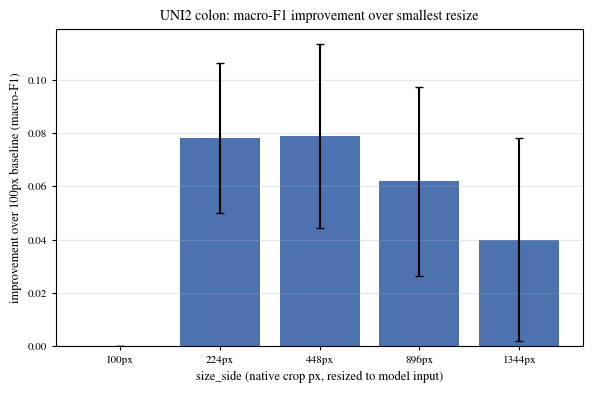

In [104]:
def build_resize_sweep_table(dataset: str = "colon"):
    sizes = sorted(UNI2_RESIZE_SWEEP)  # ascending, e.g. [100, 224, 896, 1344]
    baseline_size = sizes[0]
    baseline_model = UNI2_RESIZE_SWEEP[baseline_size]
    baseline_token = UNI2_RESIZE_SWEEP_TOKENS[baseline_size]
    print(f"[baseline] smallest available size_side = {baseline_size}px "
          f"({baseline_model} | {baseline_token})")

    rows = []
    for size in sizes:
        model = UNI2_RESIZE_SWEEP[size]
        token = UNI2_RESIZE_SWEEP_TOKENS[size]
        m, s, n = mean_std_n(CLASSIFIER_DF, dataset, model, token)
        imp_m, imp_s, imp_n = paired_diff(CLASSIFIER_DF, dataset, model, token,
                                           baseline_model, baseline_token)
        rows.append({"size_side_px": size, "model_name": model, "embeddings": token,
                     "macro_f1_mean": m, "macro_f1_std": s, "n_splits": n,
                     "improvement_over_smallest_mean": imp_m, "improvement_over_smallest_std": imp_s,
                     "improvement_over_smallest_n": imp_n})
    print(f"[colon] expected {EXPECTED_SPLITS['colon']} LOSO splits per size.")
    return pd.DataFrame(rows)


_resize_df = build_resize_sweep_table()
show_table(_resize_df.round(4), "uni2_colon_resize_sweep")

_plot_df = _resize_df[_resize_df["improvement_over_smallest_n"] > 0]
if not _plot_df.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(_plot_df))
    ax.bar(x, _plot_df["improvement_over_smallest_mean"], yerr=_plot_df["improvement_over_smallest_std"], capsize=3,
           color="#4C72B0")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}px" for s in _plot_df["size_side_px"]])
    ax.set_xlabel("size_side (native crop px, resized to model input)")
    ax.set_ylabel(f"improvement over {_resize_df['size_side_px'].min()}px baseline (macro-F1)")
    ax.set_title("UNI2 colon: macro-F1 improvement over smallest resize")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    save_fig(fig, "uni2_colon_resize_sweep")
    plt.show()
else:
    print("[skip plot] no size has a paired improvement value yet -- see [missing]/0-n rows above.")

## 4. Neighbor-cell-type baseline at multiple radii (56/112/224/448px)

Extends `saved_cells_deep_dive.ipynb`'s \u00a73 (`evaluate_neighbor_baseline`,
originally 112/224px only) to 56/112/224/448px. For each `radius_px`: majority
**ground-truth** label among same-WSI neighbors within that radius (self excluded),
scored against `true_label` the same way the model itself is scored -- a purely
spatial diagnostic upper bound, not a real classifier. Needs `test_predictions.csv`
(`training.save_test_predictions: true`, colon only) and `patch_coordinates.h5`
(`XENIUM_PROCESSED_OUTPUT_ROOT`).

In [105]:
from sklearn.metrics import f1_score, balanced_accuracy_score  # noqa: E402

NEIGHBOR_RADII_PX = [56, 112, 224, 448]

# (model_name, embeddings) pairs to evaluate -- add rows here for more conditions.
NEIGHBOR_TEST_PREDICTIONS = [
    {"model_name": UNI2_NATIVE, "embeddings": TOKEN_CLS},
    {"model_name": UNI2_NATIVE, "embeddings": TOKEN_CENTRAL},
]
NEIGHBOR_MAPPING = "simplified_broad"
NEIGHBOR_MATCHING = "all_cells"


def load_test_predictions(root: Path, model_name: str, embeddings: str,
                           correction_name: str = CORRECTION_NAME, mapping: str = NEIGHBOR_MAPPING,
                           matching: str = NEIGHBOR_MATCHING) -> pd.DataFrame:
    base = root / model_name / correction_name / mapping / matching / embeddings
    if not base.exists():
        print(f"[missing] {base}")
        return pd.DataFrame()
    frames = []
    for split_dir in sorted(base.glob("split_*")):
        csv_path = split_dir / "test_predictions.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df["correct"] = df["correct"].astype(bool)
        df["split_idx"] = int(split_dir.name.removeprefix("split_"))
        df["model_name"], df["embeddings"] = model_name, embeddings
        frames.append(df)
    if not frames:
        print(f"[no test_predictions.csv found under] {base}")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


_COORDS_CACHE: dict[str, pd.DataFrame] = {}


def get_patch_coordinates(wsi: str) -> pd.DataFrame:
    if wsi not in _COORDS_CACHE:
        path = P.XENIUM_PROCESSED_OUTPUT_ROOT / wsi / "patch_coordinates.h5"
        with h5py.File(path, "r") as f:
            x_start, y_start = f["x_start"][:], f["y_start"][:]
            raw_ids = f["cell_id"][:]
        cell_id = np.array([c.decode() if isinstance(c, bytes) else c for c in raw_ids])
        _COORDS_CACHE[wsi] = pd.DataFrame({"cell_id": cell_id, "x_centroid_px": x_start + 112, "y_centroid_px": y_start + 112})
    return _COORDS_CACHE[wsi]


def attach_pixel_coords(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    out = []
    for wsi, group in df.groupby("wsi"):
        coords = get_patch_coordinates(wsi).set_index("cell_id")[["x_centroid_px", "y_centroid_px"]]
        out.append(group.join(coords, on="cell_id"))
    return pd.concat(out, ignore_index=True)


_NEIGHBOR_MAJORITY_CACHE: dict[tuple, tuple[frozenset, pd.Series]] = {}


def neighbor_majority_predictions(df_with_coords: pd.DataFrame, radius_px: float,
                                   label_col: str = "true_label") -> pd.Series:
    preds = pd.Series(index=df_with_coords.index, dtype=object)
    for wsi, group in df_with_coords.groupby("wsi"):
        cache_key = (wsi, radius_px, label_col)
        cell_ids = frozenset(group["cell_id"])
        cached = _NEIGHBOR_MAJORITY_CACHE.get(cache_key)
        if cached is not None and cached[0] == cell_ids:
            by_cell_id = cached[1]
        else:
            xy = group[["x_centroid_px", "y_centroid_px"]].values
            tree = cKDTree(xy)
            neighbor_lists = tree.query_ball_point(xy, r=radius_px)
            labels = group[label_col].values
            result = pd.Series(index=group.index, dtype=object)
            for local_i, (row_idx, neighbors) in enumerate(zip(group.index, neighbor_lists)):
                others = [n for n in neighbors if n != local_i]
                if not others:
                    continue
                vals, counts = np.unique(labels[others], return_counts=True)
                result.loc[row_idx] = vals[np.argmax(counts)]
            by_cell_id = pd.Series(result.values, index=group["cell_id"].values)
            _NEIGHBOR_MAJORITY_CACHE[cache_key] = (cell_ids, by_cell_id)
        preds.loc[group.index] = by_cell_id.reindex(group["cell_id"].values).values
    return preds


def evaluate_neighbor_baseline(df_with_coords: pd.DataFrame, radii_px=tuple(NEIGHBOR_RADII_PX)) -> pd.DataFrame:
    rows = []
    for r in radii_px:
        pred = neighbor_majority_predictions(df_with_coords, r)
        mask = pred.notna()
        rows.append({
            "radius_px": r, "coverage": mask.mean(),
            "macro_f1": f1_score(df_with_coords.loc[mask, "true_label"], pred[mask], average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(df_with_coords.loc[mask, "true_label"], pred[mask]),
            "accuracy": (df_with_coords.loc[mask, "true_label"].values == pred[mask].values).mean(),
        })
    rows.append({
        "radius_px": "model (own prediction)", "coverage": 1.0,
        "macro_f1": f1_score(df_with_coords["true_label"], df_with_coords["predicted_label"], average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(df_with_coords["true_label"], df_with_coords["predicted_label"]),
        "accuracy": df_with_coords["correct"].mean(),
    })
    return pd.DataFrame(rows)


for _spec in NEIGHBOR_TEST_PREDICTIONS:
    _df = load_test_predictions(CLASSIFIER_ROOTS["colon"], **_spec)
    if _df.empty:
        continue
    _df_coords = attach_pixel_coords(_df)
    print(f"\n=== {_spec['model_name']} | {_spec['embeddings']}: neighbor-majority baseline vs. model ===")
    show_table(evaluate_neighbor_baseline(_df_coords).round(4),
               f"neighbor_baseline_{_spec['model_name']}_{_spec['embeddings']}")


[no test_predictions.csv found under] ../outputs_classifier_colon/UNI2/raw/simplified_broad/all_cells/cls
[no test_predictions.csv found under] ../outputs_classifier_colon/UNI2/raw/simplified_broad/all_cells/bottom_left_bottom_right_top_left_top_right


## 5. Probing: `cell_count` / `cell_density`, central vs. CLS, 100-resized vs. native

4 models \u00d7 2 resolutions (100px-resized, native/224) \u00d7 2 tokens (central, CLS)
\u00d7 2 probes (`cell_count`, `cell_density`) \u00d7 3 context windows (224/448/1344px,
`configs/probing_colon.yaml`'s `probes.cell_count`/`cell_density.context_px`) --
`test_selection_metric` (R\u00b2). Raw table first (long format, mean \u00b1 std across
LOSO splits); diff table is `central - CLS`, **native resolution only**, paired
per split.

In [106]:
def build_probe_raw_table(models: list[str] = FOUNDATION_MODELS_PROBING,
                           probes: list[str] = CONTEXT_PROBES_OF_INTEREST,
                           context_px_list: list[int] = CONTEXT_PX_LIST):
    rows = []
    for model in models:
        label = MODEL_LABELS.get(model, model)
        resized_model = RESOLUTION_FAMILIES_BY_NATIVE.get(model)
        for res_label, res_model in (("native", model), ("100resized", resized_model)):
            if res_model is None:
                continue
            for token in (TOKEN_CENTRAL, TOKEN_CLS):
                for probe in probes:
                    for cpx in context_px_list:
                        pkey = probe_key(probe, cpx)
                        m, s, n = mean_std_metric_probe(PROBE_DF, res_model, token, pkey)
                        rows.append({"model": label, "resolution": res_label, "token": TOKEN_LABELS.get(token, token),
                                     "probe": probe, "context_px": cpx, "test_r2_mean": m, "test_r2_std": s, "n_splits": n})
    return pd.DataFrame(rows)


def build_probe_diff_table(models: list[str] = FOUNDATION_MODELS_PROBING,
                            probes: list[str] = CONTEXT_PROBES_OF_INTEREST,
                            context_px_list: list[int] = CONTEXT_PX_LIST):
    rows = []
    for model in models:
        for probe in probes:
            for cpx in context_px_list:
                pkey = probe_key(probe, cpx)
                d_mean, d_std, d_n = paired_diff_probe(PROBE_DF, model, TOKEN_CENTRAL, model, TOKEN_CLS, pkey)
                rows.append({"model": MODEL_LABELS.get(model, model), "probe": probe, "context_px": cpx,
                             "central_minus_cls_mean": d_mean, "central_minus_cls_std": d_std, "n_splits": d_n})
    return pd.DataFrame(rows)


print(f"[colon] expected {EXPECTED_SPLITS_PROBING} LOSO splits per condition.")
_probe_raw_df = build_probe_raw_table()
_n_missing = (_probe_raw_df["n_splits"] == 0).sum()
if _n_missing:
    print(f"[warning] {_n_missing}/{len(_probe_raw_df)} (model, resolution, token, probe, context_px) rows have 0 fitted splits.")
show_table(_probe_raw_df.round(4), "probe_cellcount_density_raw")

_probe_diff_df = build_probe_diff_table()
show_table(_probe_diff_df.round(4), "probe_cellcount_density_diff_central_minus_cls")


[colon] expected 8 LOSO splits per condition.
[warning] 2/32 (model, resolution, token, probe, context_px) rows have 0 fitted splits.


,model,resolution,token,probe,context_px,test_r2_mean,test_r2_std,n_splits
0,UNI2,native,central (4-token avg),cell_count,224,0.4268,0.3328,8
1,UNI2,native,central (4-token avg),cell_type_composition,224,0.4156,0.1189,8
2,UNI2,native,CLS,cell_count,224,0.0358,0.9202,8
3,UNI2,native,CLS,cell_type_composition,224,0.3933,0.1701,8
4,UNI2,100resized,central (4-token avg),cell_count,224,-0.4500,1.4132,8
5,UNI2,100resized,central (4-token avg),cell_type_composition,224,0.0950,0.2451,8
6,UNI2,100resized,CLS,cell_count,224,-1.2185,3.0331,8
7,UNI2,100resized,CLS,cell_type_composition,224,0.1376,0.2160,8
8,H-Optimus-1,native,central (4-token avg),cell_count,224,0.4125,0.3519,8
9,H-Optimus-1,native,central (4-token avg),cell_type_composition,224,0.3736,0.1537,8


\begin{table}
\caption{probe cellcount density raw}
\label{tab:probe_cellcount_density_raw}
\begin{tabular}{llllrrrr}
\toprule
model & resolution & token & probe & context_px & test_r2_mean & test_r2_std & n_splits \\
\midrule
UNI2 & native & central (4-token avg) & cell_count & 224 & 0.4268 & 0.3328 & 8 \\
UNI2 & native & central (4-token avg) & cell_type_composition & 224 & 0.4156 & 0.1189 & 8 \\
UNI2 & native & CLS & cell_count & 224 & 0.0358 & 0.9202 & 8 \\
UNI2 & native & CLS & cell_type_composition & 224 & 0.3933 & 0.1701 & 8 \\
UNI2 & 100resized & central (4-token avg) & cell_count & 224 & -0.4500 & 1.4132 & 8 \\
UNI2 & 100resized & central (4-token avg) & cell_type_composition & 224 & 0.0950 & 0.2451 & 8 \\
UNI2 & 100resized & CLS & cell_count & 224 & -1.2185 & 3.0331 & 8 \\
UNI2 & 100resized & CLS & cell_type_composition & 224 & 0.1376 & 0.2160 & 8 \\
H-Optimus-1 & native & central (4-token avg) & cell_count & 224 & 0.4125 & 0.3519 & 8 \\
H-Optimus-1 & native & central (4-toke

,model,probe,context_px,central_minus_cls_mean,central_minus_cls_std,n_splits
0,UNI2,cell_count,224,0.3911,0.5973,8
1,UNI2,cell_type_composition,224,0.0223,0.0879,8
2,H-Optimus-1,cell_count,224,0.5131,1.0125,8
3,H-Optimus-1,cell_type_composition,224,-0.0031,0.0567,8
4,Phikon-v2,cell_count,224,NaN,NaN,0
5,Phikon-v2,cell_type_composition,224,NaN,NaN,0
6,Virchow2,cell_count,224,0.1328,0.4282,8
7,Virchow2,cell_type_composition,224,-0.0363,0.1167,8


\begin{table}
\caption{probe cellcount density diff central minus cls}
\label{tab:probe_cellcount_density_diff_central_minus_cls}
\begin{tabular}{llrrrr}
\toprule
model & probe & context_px & central_minus_cls_mean & central_minus_cls_std & n_splits \\
\midrule
UNI2 & cell_count & 224 & 0.3911 & 0.5973 & 8 \\
UNI2 & cell_type_composition & 224 & 0.0223 & 0.0879 & 8 \\
H-Optimus-1 & cell_count & 224 & 0.5131 & 1.0125 & 8 \\
H-Optimus-1 & cell_type_composition & 224 & -0.0031 & 0.0567 & 8 \\
Phikon-v2 & cell_count & 224 & NaN & NaN & 0 \\
Phikon-v2 & cell_type_composition & 224 & NaN & NaN & 0 \\
Virchow2 & cell_count & 224 & 0.1328 & 0.4282 & 8 \\
Virchow2 & cell_type_composition & 224 & -0.0363 & 0.1167 & 8 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/probe_cellcount_density_diff_central_minus_cls.tex


,model,probe,context_px,central_minus_cls_mean,central_minus_cls_std,n_splits
0,UNI2,cell_count,224,0.3911,0.5973,8
1,UNI2,cell_type_composition,224,0.0223,0.0879,8
2,H-Optimus-1,cell_count,224,0.5131,1.0125,8
3,H-Optimus-1,cell_type_composition,224,-0.0031,0.0567,8
4,Phikon-v2,cell_count,224,NaN,NaN,0
5,Phikon-v2,cell_type_composition,224,NaN,NaN,0
6,Virchow2,cell_count,224,0.1328,0.4282,8
7,Virchow2,cell_type_composition,224,-0.0363,0.1167,8


## 6. Probing: Phikon-v2 `area` probe, masked vs. unmasked (nucleus token)

`area`: the probed cell's own Xenium boundary-polygon area (log1p-regressed,
independent of any context window). `PhikonV2_448` (unmasked) vs.
`PhikonV2_448_masked` (central 3x3 tokens masked at inference), both read via the
`nucleus` embeddings segment (`MASK_TOKEN` in CONFIG).

In [107]:
def build_mask_probe_tables():
    unmasked, masked = MASK_COMPARISON["unmasked"], MASK_COMPARISON["masked"]
    m_u, s_u, n_u = mean_std_metric_probe(PROBE_DF, unmasked, TOKEN_CENTRAL, CELL_LEVEL_PROBE)
    m_m, s_m, n_m = mean_std_metric_probe(PROBE_DF, masked, TOKEN_CENTRAL, CELL_LEVEL_PROBE)
    raw = pd.DataFrame([
        {"condition": "unmasked", "model_name": unmasked, "test_r2_mean": m_u, "test_r2_std": s_u, "n_splits": n_u},
        {"condition": "masked",   "model_name": masked,   "test_r2_mean": m_m, "test_r2_std": s_m, "n_splits": n_m},
    ])
    d_mean, d_std, d_n = paired_diff_probe(PROBE_DF, unmasked, MASK_TOKEN, masked, TOKEN_CENTRAL, CELL_LEVEL_PROBE)
    diff = pd.DataFrame([{"probe": CELL_LEVEL_PROBE, "comparison": "unmasked - masked",
                          "diff_mean": d_mean, "diff_std": d_std, "n_splits": d_n}])
    return raw, diff


print(f"[colon] expected {EXPECTED_SPLITS_PROBING} LOSO splits per condition.")
_mask_probe_raw, _mask_probe_diff = build_mask_probe_tables()
show_table(_mask_probe_raw.round(4), "phikon_area_probe_masked_vs_unmasked_raw")
show_table(_mask_probe_diff.round(4), "phikon_area_probe_masked_vs_unmasked_diff")


[colon] expected 8 LOSO splits per condition.


,condition,model_name,test_r2_mean,test_r2_std,n_splits
0,unmasked,PhikonV2_448,0.2659,0.0468,8
1,masked,PhikonV2_448_masked,0.0690,0.0318,8


\begin{table}
\caption{phikon area probe masked vs unmasked raw}
\label{tab:phikon_area_probe_masked_vs_unmasked_raw}
\begin{tabular}{llrrr}
\toprule
condition & model_name & test_r2_mean & test_r2_std & n_splits \\
\midrule
unmasked & PhikonV2_448 & 0.2659 & 0.0468 & 8 \\
masked & PhikonV2_448_masked & 0.0690 & 0.0318 & 8 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/phikon_area_probe_masked_vs_unmasked_raw.tex


,probe,comparison,diff_mean,diff_std,n_splits
0,area,unmasked - masked,NaN,NaN,0


\begin{table}
\caption{phikon area probe masked vs unmasked diff}
\label{tab:phikon_area_probe_masked_vs_unmasked_diff}
\begin{tabular}{llrrr}
\toprule
probe & comparison & diff_mean & diff_std & n_splits \\
\midrule
area & unmasked - masked & NaN & NaN & 0 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/phikon_area_probe_masked_vs_unmasked_diff.tex


,probe,comparison,diff_mean,diff_std,n_splits
0,area,unmasked - masked,NaN,NaN,0


## 7. Classification: Phikon-v2 colon classification, masked vs. unmasked (nucleus token)

Same masked/unmasked Phikon-v2 pair as section 6, but for the colon cell-type
**classification** task (`outputs_classifier_colon`), `nucleus` embeddings
segment (`MASK_TOKEN` in CONFIG), macro-F1.

In [108]:
def build_mask_classifier_tables(dataset: str = "colon"):
    unmasked, masked = MASK_COMPARISON["unmasked"], MASK_COMPARISON["masked"]
    m_u, s_u, n_u = mean_std_n(CLASSIFIER_DF, dataset, unmasked, MASK_TOKEN)
    m_m, s_m, n_m = mean_std_n(CLASSIFIER_DF, dataset, masked, MASK_TOKEN)
    raw = pd.DataFrame([
        {"condition": "unmasked", "model_name": unmasked, "macro_f1_mean": m_u, "macro_f1_std": s_u, "n_splits": n_u},
        {"condition": "masked",   "model_name": masked,   "macro_f1_mean": m_m, "macro_f1_std": s_m, "n_splits": n_m},
    ])
    d_mean, d_std, d_n = paired_diff(CLASSIFIER_DF, dataset, unmasked, MASK_TOKEN, masked, MASK_TOKEN)
    diff = pd.DataFrame([{"comparison": "unmasked - masked", "diff_mean": d_mean, "diff_std": d_std, "n_splits": d_n}])
    return raw, diff


print(f"[colon] expected {EXPECTED_SPLITS['colon']} LOSO splits per condition.")
_mask_clf_raw, _mask_clf_diff = build_mask_classifier_tables()
show_table(_mask_clf_raw.round(4), "phikon_colon_classification_masked_vs_unmasked_raw")
show_table(_mask_clf_diff.round(4), "phikon_colon_classification_masked_vs_unmasked_diff")


[colon] expected 8 LOSO splits per condition.


,condition,model_name,macro_f1_mean,macro_f1_std,n_splits
0,unmasked,PhikonV2_448,0.6391,0.1037,8
1,masked,PhikonV2_448_masked,0.6079,0.1023,8


\begin{table}
\caption{phikon colon classification masked vs unmasked raw}
\label{tab:phikon_colon_classification_masked_vs_unmasked_raw}
\begin{tabular}{llrrr}
\toprule
condition & model_name & macro_f1_mean & macro_f1_std & n_splits \\
\midrule
unmasked & PhikonV2_448 & 0.6391 & 0.1037 & 8 \\
masked & PhikonV2_448_masked & 0.6079 & 0.1023 & 8 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/phikon_colon_classification_masked_vs_unmasked_raw.tex


,comparison,diff_mean,diff_std,n_splits
0,unmasked - masked,0.0311,0.0066,8


\begin{table}
\caption{phikon colon classification masked vs unmasked diff}
\label{tab:phikon_colon_classification_masked_vs_unmasked_diff}
\begin{tabular}{lrrr}
\toprule
comparison & diff_mean & diff_std & n_splits \\
\midrule
unmasked - masked & 0.0311 & 0.0066 & 8 \\
\bottomrule
\end{tabular}
\end{table}

[saved] tables_for_paper/phikon_colon_classification_masked_vs_unmasked_diff.tex


,comparison,diff_mean,diff_std,n_splits
0,unmasked - masked,0.0311,0.0066,8


## 8. Classification: UNI2 cross-cancer, central vs. default tokens

`UNI2` (`UNI2_NATIVE`) on the cross-cancer classification task:
`embeddings=central` (the 4-corner average) vs. `embeddings=default` (average of
every `embeddings_*` key found in the h5 file -- mixes in CLS/boundary tokens too).
Cross-cancer and colon both store the native UNI2 cls/central runs under the same
`UNI2` folder, so this uses `UNI2_NATIVE` like sections 1, 2 and 4 do.

In [16]:
_UNI2_CROSS_CANCER_MODEL = UNI2_NATIVE  # confirmed: cross-cancer and colon both use the "UNI2" folder


def build_uni2_default_vs_central_table(dataset: str = "cross_cancer", model: str = _UNI2_CROSS_CANCER_MODEL):
    m_c, s_c, n_c = mean_std_n(CLASSIFIER_DF, dataset, model, TOKEN_CENTRAL)
    m_d, s_d, n_d = mean_std_n(CLASSIFIER_DF, dataset, model, TOKEN_DEFAULT)
    raw = pd.DataFrame([
        {"token": "central", "macro_f1_mean": m_c, "macro_f1_std": s_c, "n_splits": n_c},
        {"token": "default", "macro_f1_mean": m_d, "macro_f1_std": s_d, "n_splits": n_d},
    ])
    d_mean, d_std, d_n = paired_diff(CLASSIFIER_DF, dataset, model, TOKEN_DEFAULT, model, TOKEN_CENTRAL)
    diff = pd.DataFrame([{"comparison": "default - central", "diff_mean": d_mean, "diff_std": d_std, "n_splits": d_n}])
    return raw, diff


print(f"[cross_cancer] expected {EXPECTED_SPLITS['cross_cancer']} LOSO splits per condition.")
_uni2_dc_raw, _uni2_dc_diff = build_uni2_default_vs_central_table()
show_table(_uni2_dc_raw.round(4), "uni2_cross_cancer_default_vs_central_raw")
show_table(_uni2_dc_diff.round(4), "uni2_cross_cancer_default_vs_central_diff")


[cross_cancer] expected 14 LOSO splits per condition.


,token,macro_f1_mean,macro_f1_std,n_splits
0,central,0.5545,0.0961,14
1,default,0.5325,0.0956,14


\begin{table}
\caption{uni2 cross cancer default vs central raw}
\label{tab:uni2_cross_cancer_default_vs_central_raw}
\begin{tabular}{lrrr}
\toprule
token & macro_f1_mean & macro_f1_std & n_splits \\
\midrule
central & 0.5545 & 0.0961 & 14 \\
default & 0.5325 & 0.0956 & 14 \\
\bottomrule
\end{tabular}
\end{table}



,comparison,diff_mean,diff_std,n_splits
0,default - central,-0.022,0.0229,14


\begin{table}
\caption{uni2 cross cancer default vs central diff}
\label{tab:uni2_cross_cancer_default_vs_central_diff}
\begin{tabular}{lrrr}
\toprule
comparison & diff_mean & diff_std & n_splits \\
\midrule
default - central & -0.0220 & 0.0229 & 14 \\
\bottomrule
\end{tabular}
\end{table}



,comparison,diff_mean,diff_std,n_splits
0,default - central,-0.022,0.0229,14


## 9. Masking-drift vs. biological difference: top/bottom-drift cell distributions

From `analyse_probing_results.ipynb`'s "Top-drift vs. bottom-drift cells" section
(group-contrast version of its drift-vs-biological-difference correlation test).
**Enhanced here**: instead of a boxplot with back-to-back marginal histograms, both
groups' distributions are drawn overlaid on the same axes, together with the
distribution over *all* cells (not just the two extreme groups), plus the same
WSI-cluster-bootstrap statistical test annotated directly on the plot.

Re-reads raw `embeddings_dataset.h5` / `patch_coordinates.h5` / `adata.h5ad` files
directly (bypasses the probing pipeline's own subsampling) -- needs a masked/unmasked
model pair to already be probed (`PROBE_DF` above) plus `DATASETS_ROOT` /
`XENIUM_PROCESSED_OUTPUT_ROOT` set.

In [17]:
import anndata as ad  # noqa: E402
from src.python.probing.data.cell_population import PopulationCache  # noqa: E402
from src.python.probing.probes.base import group_ranges  # noqa: E402

_known_runs = set(zip(PROBE_DF["model_name"], PROBE_DF["correction_name"])) if not PROBE_DF.empty else set()
MASKED_UNMASKED_PAIRS = sorted(
    (masked[: -len("_masked")], masked, correction)
    for masked, correction in _known_runs
    if masked.endswith("_masked") and (masked[: -len("_masked")], correction) in _known_runs
)
print("Detected masked/unmasked pairs:", MASKED_UNMASKED_PAIRS)

TOP_BOTTOM_DRIFT_FRAC = 0.05   # top/bottom 5% of cells by drift (pooled across WSIs)
DRIFT_CONTEXT_PX = 448          # matches these runs' size_side=448 field of view
DRIFT_MIN_NEIGHBORS = 3

# ── result cache (this section's compute_drift/compute_neighbor_type_stats/
# compute_expression_divergence pipeline re-reads raw h5/adata files per WSI and is
# slow) -- the assembled analysis_df is cached to disk so the plotting cell below
# can be iterated on (styling, bins, annotations, ...) without recomputing, even
# across kernel restarts / days later. Set DRIFT_FORCE_RECOMPUTE = True to ignore
# an existing cache (e.g. after a new masked/unmasked run lands in PROBE_DF, or
# after changing DRIFT_CONTEXT_PX/DRIFT_MIN_NEIGHBORS above).
DRIFT_CACHE_DIR = Path("cached_results")
DRIFT_ANALYSIS_CACHE = DRIFT_CACHE_DIR / "drift_analysis_df.parquet"
DRIFT_ANALYSIS_CACHE_META = DRIFT_CACHE_DIR / "drift_analysis_df.meta.json"
DRIFT_FORCE_RECOMPUTE = False


Detected masked/unmasked pairs: [('PhikonV2_448', 'PhikonV2_448_masked', 'raw')]


In [92]:
from matplotlib.lines import Line2D  # noqa: E402
from scipy.stats import gaussian_kde  # noqa: E402


def _decode_str_array(arr: np.ndarray) -> np.ndarray:
    if len(arr) and isinstance(arr[0], (bytes, bytearray)):
        return np.array([x.decode("utf-8") for x in arr])
    return arr


def _load_raw_cell_embeddings(base_path, wsi_name: str, embeddings_datasets: list[str]):
    with h5py.File(os.path.join(base_path, wsi_name, "embeddings_dataset.h5"), "r") as f:
        datasets = embeddings_datasets or [k.split("embeddings_")[1] for k in f.keys() if k.startswith("embeddings_")]
        embeddings = np.mean([f[f"embeddings_{k}"][()] for k in datasets], axis=0).astype(np.float64)
        cell_ids = _decode_str_array(f["cell_ids"][()])
    return cell_ids, embeddings


def _cosine_distance(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a_n = a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-12, None)
    b_n = b / np.clip(np.linalg.norm(b, axis=1, keepdims=True), 1e-12, None)
    return 1.0 - np.sum(a_n * b_n, axis=1)


def compute_drift(unmasked_model: str, masked_model: str, correction_name: str,
                   embeddings_datasets: list[str]) -> pd.DataFrame:
    unmasked_base = os.path.join(P.DATASETS_ROOT, f"{unmasked_model}_h5", correction_name)
    masked_base = os.path.join(P.DATASETS_ROOT, f"{masked_model}_h5", correction_name)
    wsi_names = sorted(set(os.listdir(unmasked_base)) & set(os.listdir(masked_base)))
    if not wsi_names:
        raise ValueError(f"No shared WSI directories between {unmasked_base!r} and {masked_base!r}")
    rows = []
    for wsi_name in wsi_names:
        ids_u, emb_u = _load_raw_cell_embeddings(unmasked_base, wsi_name, embeddings_datasets)
        ids_m, emb_m = _load_raw_cell_embeddings(masked_base, wsi_name, embeddings_datasets)
        common, iu, im = np.intersect1d(ids_u, ids_m, return_indices=True)
        if len(common) == 0:
            print(f"[warning] {wsi_name}: no cell_ids shared between {unmasked_model} and {masked_model}")
            continue
        drift = _cosine_distance(emb_u[iu], emb_m[im])
        rows.append(pd.DataFrame({"wsi_name": wsi_name, "cell_id": common, "drift": drift}))
    return pd.concat(rows, ignore_index=True)


def _pearson_corr(a, b):
    a, b = a - a.mean(), b - b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else np.nan


def _cosine_dist_vec(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(1.0 - np.dot(a, b) / denom) if denom > 0 else np.nan


def _xenium_barcode(cell_id: str) -> str:
    return cell_id.split("_")[-1]


def compute_neighbor_type_stats(df: pd.DataFrame, mapping_name: str, context_px: float) -> pd.DataFrame:
    mapping = mapping_factory(mapping_name)
    pop_cache = PopulationCache(P.XENIUM_PROCESSED_OUTPUT_ROOT, mapping)
    half = context_px / 2.0
    n = len(df)
    position_found = np.zeros(n, dtype=bool)
    n_neighbors = np.zeros(n, dtype=np.int64)
    heterotypic_frac = np.full(n, np.nan)

    wsi_names = df["wsi_name"].to_numpy()
    cell_ids = df["cell_id"].to_numpy()
    order = np.argsort(wsi_names, kind="stable")
    sorted_wsi = wsi_names[order]
    for start, end in group_ranges(sorted_wsi):
        wsi_name = sorted_wsi[start]
        pop = pop_cache.get(wsi_name)
        local_idx = order[start:end]
        rows = np.array([pop.id_to_row.get(cid, -1) for cid in cell_ids[local_idx]])
        valid = rows >= 0
        if not valid.any():
            continue
        v_idx, v_rows = local_idx[valid], rows[valid]
        position_found[v_idx] = True
        neighbor_lists = pop.query_windows(pop.x[v_rows], pop.y[v_rows], half)
        for li, row, neighbors in zip(v_idx.tolist(), v_rows.tolist(), neighbor_lists):
            neighbors = np.asarray(neighbors, dtype=np.int64)
            neighbors = neighbors[neighbors != row]
            n_neighbors[li] = len(neighbors)
            if len(neighbors) > 0:
                same = np.count_nonzero(pop.class_idx[neighbors] == pop.class_idx[row])
                heterotypic_frac[li] = 1.0 - same / len(neighbors)

    out = df.copy()
    out["position_found"] = position_found
    out["n_type_neighbors"] = n_neighbors
    out["heterotypic_frac"] = heterotypic_frac
    out["isolated"] = position_found & (n_neighbors == 0)
    return out


def _load_adata_population(wsi_name: str, target_sum: float = 100.0) -> dict:
    path = os.path.join(str(P.XENIUM_PROCESSED_OUTPUT_ROOT), wsi_name, "adata.h5ad")
    adata = ad.read_h5ad(path)
    counts = adata.layers["counts"]
    counts = np.asarray(counts.todense() if hasattr(counts, "todense") else counts, dtype=np.float64)
    lib_size = counts.sum(axis=1, keepdims=True)
    lib_size[lib_size == 0] = 1.0
    expr = np.log1p(counts / lib_size * target_sum)
    cell_id = _decode_str_array(np.asarray(adata.obs["cell_id"].to_numpy()))
    x = adata.obs["x_centroid"].to_numpy(dtype=np.float64)
    y = adata.obs["y_centroid"].to_numpy(dtype=np.float64)
    tree = cKDTree(np.column_stack([x, y]))
    return {"x": x, "y": y, "expr": expr, "tree": tree, "id_to_row": {cid: i for i, cid in enumerate(cell_id)}}


_ADATA_POP_CACHE: dict[str, dict] = {}


def _get_adata_population(wsi_name: str) -> dict:
    if wsi_name not in _ADATA_POP_CACHE:
        _ADATA_POP_CACHE[wsi_name] = _load_adata_population(wsi_name)
    return _ADATA_POP_CACHE[wsi_name]


def compute_expression_divergence(df: pd.DataFrame, context_px: float, min_neighbors: int) -> pd.DataFrame:
    n = len(df)
    cos_dist = np.full(n, np.nan)
    half = context_px / 2.0
    wsi_names = df["wsi_name"].to_numpy()
    cell_ids = df["cell_id"].to_numpy()
    order = np.argsort(wsi_names, kind="stable")
    sorted_wsi = wsi_names[order]
    for start, end in group_ranges(sorted_wsi):
        wsi_name = sorted_wsi[start]
        pop = _get_adata_population(wsi_name)
        local_idx = order[start:end]
        rows = np.array([pop["id_to_row"].get(_xenium_barcode(cid), -1) for cid in cell_ids[local_idx]])
        valid = rows >= 0
        if not valid.any():
            continue
        v_idx, v_rows = local_idx[valid], rows[valid]
        neighbor_lists = pop["tree"].query_ball_point(
            np.column_stack([pop["x"][v_rows], pop["y"][v_rows]]), r=half, p=np.inf, workers=-1
        )
        for li, row, neighbors in zip(v_idx.tolist(), v_rows.tolist(), neighbor_lists):
            neighbors = np.asarray(neighbors, dtype=np.int64)
            neighbors = neighbors[neighbors != row]
            if len(neighbors) < min_neighbors:
                continue
            neighborhood_mean = pop["expr"][neighbors].mean(axis=0)
            cos_dist[li] = _cosine_dist_vec(pop["expr"][row], neighborhood_mean)
    out = df.copy()
    out["expr_cosine_dist_to_neighbors"] = cos_dist
    return out


def cluster_bootstrap_group_diff(values: np.ndarray, mask_a: np.ndarray, mask_b: np.ndarray, groups: np.ndarray,
                                  n_boot: int = 2000, seed: int = 0) -> dict:
    values, mask_a, mask_b, groups = np.asarray(values), np.asarray(mask_a), np.asarray(mask_b), np.asarray(groups)
    valid = np.isfinite(values) & (mask_a | mask_b)
    values, mask_a, mask_b, groups = values[valid], mask_a[valid], mask_b[valid], groups[valid]
    wsi_u = np.unique(groups)
    rng = np.random.default_rng(seed)
    if mask_a.sum() == 0 or mask_b.sum() == 0:
        return {"n_a": int(mask_a.sum()), "n_b": int(mask_b.sum()), "median_diff": np.nan,
                "ci_lo": np.nan, "ci_hi": np.nan, "mannwhitney_p_naive_iid": np.nan}
    obs = float(np.median(values[mask_a]) - np.median(values[mask_b]))
    boot = []
    for _ in range(n_boot):
        sampled = rng.choice(wsi_u, size=len(wsi_u), replace=True)
        idx = np.concatenate([np.flatnonzero(groups == w) for w in sampled])
        d, a, b = values[idx], mask_a[idx], mask_b[idx]
        if a.any() and b.any():
            boot.append(np.median(d[a]) - np.median(d[b]))
    boot = np.array(boot)
    if len(boot) == 0:
        ci_lo = ci_hi = np.nan
    else:
        ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    _, u_p = stats.mannwhitneyu(values[mask_a], values[mask_b], alternative="greater")
    return {"n_a": int(mask_a.sum()), "n_b": int(mask_b.sum()), "median_diff": obs,
            "ci_lo": float(ci_lo), "ci_hi": float(ci_hi), "mannwhitney_p_naive_iid": float(u_p)}


def top_bottom_drift_masks(df: pd.DataFrame, frac: float = TOP_BOTTOM_DRIFT_FRAC):
    drift = df["drift"].to_numpy()
    valid = np.isfinite(drift)
    lo_thresh = np.nanpercentile(drift[valid], frac * 100)
    hi_thresh = np.nanpercentile(drift[valid], (1 - frac) * 100)
    bottom_mask = valid & (drift <= lo_thresh)
    top_mask = valid & (drift >= hi_thresh)
    return top_mask, bottom_mask


def draw_group_distribution(ax, values: np.ndarray, edges: np.ndarray, color: str, label: str, style: str) -> None:
    """One group's distribution, drawn in one of 3 review styles: a step-outline
    histogram (the settled default), a semi-transparent filled histogram, or a
    smoothed kernel-density curve."""
    if style == "step":
        ax.hist(values, bins=edges, density=True, histtype="step", linewidth=1.8, color=color, label=label)
    elif style == "filled":
        ax.hist(values, bins=edges, density=True, histtype="stepfilled", linewidth=1.2, alpha=0.45, color=color, label=label)
    elif style == "kde":
        xs = np.linspace(edges[0], edges[-1], 200)
        ax.plot(xs, gaussian_kde(values)(xs), linewidth=2.0, color=color, label=label)
    else:
        raise ValueError(f"unknown style {style!r}")


def draw_all_cells_distribution(ax, values: np.ndarray, edges: np.ndarray, style: str, label: str = "all cells") -> None:
    label = f"{label} (n={len(values)})"
    if style == "kde":
        xs = np.linspace(edges[0], edges[-1], 200)
        ax.fill_between(xs, gaussian_kde(values)(xs), color="0.75", alpha=0.5, label=label)
    else:
        ax.hist(values, bins=edges, density=True, color="0.75", alpha=0.6, label=label)


def plot_group_distributions_with_all(df: pd.DataFrame, value_col: str, xlabel: str,
                                      mask_top: np.ndarray, mask_bottom: np.ndarray,
                                      label_top: str, label_bottom: str,
                                      bins: int = 40, clip_pct=(0.5, 99.5),
                                      style: str = "step", show_stats: bool = False,
                                      legend_loc: str = "upper right"):
    x_all = df[value_col].to_numpy(dtype=float)
    x_all = x_all[np.isfinite(x_all)]
    top = df.loc[mask_top, value_col].dropna().to_numpy()
    bottom = df.loc[mask_bottom, value_col].dropna().to_numpy()
    lo, hi = (np.percentile(x_all, clip_pct) if clip_pct else (x_all.min(), x_all.max()))
    edges = np.linspace(lo, hi, bins + 1)

    fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))

    draw_all_cells_distribution(ax, x_all, edges, style)
    draw_group_distribution(ax, bottom, edges, COLOR_BLUE, f"{label_bottom} ($n$={len(bottom)})", style)
    draw_group_distribution(ax, top,    edges, COLOR_RED,  f"{label_top} ($n$={len(top)})", style)

    ax.set_xlabel(xlabel, labelpad=2)
    ax.set_ylabel("Density", labelpad=2)

    stat = cluster_bootstrap_group_diff(df[value_col].to_numpy(),
                                        np.asarray(mask_top), np.asarray(mask_bottom),
                                        df["wsi_name"].to_numpy())

    ax.legend(fontsize=6.5, frameon=False, loc=legend_loc,
              handlelength=1.2, handletextpad=0.5, labelspacing=0.25,
              borderaxespad=0.2)

    if show_stats:  # notebook only; the paper version puts these in the caption
        txt = (f"$\\Delta$median = {stat['median_diff']:.3g}\n"
               f"95% CI [{stat['ci_lo']:.3g}, {stat['ci_hi']:.3g}]\n"
               f"$p$ = {stat['mannwhitney_p_naive_iid']:.2g}")
        ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
                fontsize=6, color="0.25")

    ax.grid(axis="y", alpha=0.3, linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout(pad=0.2)
    save_fig(fig, f"drift_group_distributions_{value_col}_{style}")
    plt.show()
    return stat

In [19]:
import json  # noqa: E402


def save_drift_cache(analysis_df: pd.DataFrame, drift_pair: tuple, mapping_name: str) -> None:
    """Persist analysis_df (+ the parameters baked into it) so the plotting cell
    below can reload it later without re-running compute_drift/compute_neighbor_type_stats/
    compute_expression_divergence."""
    DRIFT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    analysis_df.to_parquet(DRIFT_ANALYSIS_CACHE, index=False)
    meta = {
        "drift_pair": list(drift_pair), "mapping_name": mapping_name,
        "drift_context_px": DRIFT_CONTEXT_PX, "drift_min_neighbors": DRIFT_MIN_NEIGHBORS,
        "token_central_keys": TOKEN_CENTRAL_KEYS, "n_cells": len(analysis_df),
        "computed_at": pd.Timestamp.now().isoformat(),
    }
    DRIFT_ANALYSIS_CACHE_META.write_text(json.dumps(meta, indent=2))
    print(f"[cache] wrote {DRIFT_ANALYSIS_CACHE} ({len(analysis_df)} rows) + {DRIFT_ANALYSIS_CACHE_META.name}")


def load_drift_cache() -> tuple[pd.DataFrame, dict] | None:
    if not (DRIFT_ANALYSIS_CACHE.exists() and DRIFT_ANALYSIS_CACHE_META.exists()):
        return None
    return pd.read_parquet(DRIFT_ANALYSIS_CACHE), json.loads(DRIFT_ANALYSIS_CACHE_META.read_text())


analysis_df = None
_drift_cached = None if DRIFT_FORCE_RECOMPUTE else load_drift_cache()

if _drift_cached is not None:
    analysis_df, _drift_meta = _drift_cached
    DRIFT_PAIR = tuple(_drift_meta["drift_pair"])
    mapping_name = _drift_meta["mapping_name"]
    print(f"[cache] loaded {DRIFT_ANALYSIS_CACHE} -- {len(analysis_df)} cells, drift pair {DRIFT_PAIR}, "
          f"computed {_drift_meta.get('computed_at', '?')}. Set DRIFT_FORCE_RECOMPUTE = True above to recompute "
          f"from raw files instead.")
    _stale = (_drift_meta.get("drift_context_px") != DRIFT_CONTEXT_PX
              or _drift_meta.get("drift_min_neighbors") != DRIFT_MIN_NEIGHBORS
              or _drift_meta.get("token_central_keys") != TOKEN_CENTRAL_KEYS)
    if _stale:
        print("[warning] cached analysis_df was computed with different DRIFT_CONTEXT_PX / DRIFT_MIN_NEIGHBORS / "
              "TOKEN_CENTRAL_KEYS than currently set above -- set DRIFT_FORCE_RECOMPUTE = True to refresh the cache.")
elif MASKED_UNMASKED_PAIRS:
    DRIFT_PAIR = MASKED_UNMASKED_PAIRS[0]
    print(f"Using drift pair: {DRIFT_PAIR}")
    drift_df = compute_drift(*DRIFT_PAIR, TOKEN_CENTRAL_KEYS)
    print(f"{len(drift_df)} matched cells across {drift_df['wsi_name'].nunique()} WSIs")

    _mapping_rows = PROBE_DF.loc[PROBE_DF["model_name"] == DRIFT_PAIR[0], "mapping"]
    mapping_name = _mapping_rows.iloc[0] if not _mapping_rows.empty else "simplified_broad"
    analysis_df = compute_neighbor_type_stats(drift_df, mapping_name, DRIFT_CONTEXT_PX)
    analysis_df = compute_expression_divergence(analysis_df, DRIFT_CONTEXT_PX, DRIFT_MIN_NEIGHBORS)
    print(f"{len(analysis_df)} matched cells total; {int(analysis_df['isolated'].sum())} isolated "
          f"(0 neighbours within {DRIFT_CONTEXT_PX}px).")
    save_drift_cache(analysis_df, DRIFT_PAIR, mapping_name)
else:
    print("[skip] no masked/unmasked model pair found in PROBE_DF and no cache at "
          f"{DRIFT_ANALYSIS_CACHE} -- see MASKED_UNMASKED_PAIRS above.")


[cache] loaded cached_results/drift_analysis_df.parquet -- 2129433 cells, drift pair ('PhikonV2_448', 'PhikonV2_448_masked', 'raw'), computed 2026-09-20T11:02:20.970155. Set DRIFT_FORCE_RECOMPUTE = True above to recompute from raw files instead.


### Plot from `analysis_df` (cached or freshly computed above)

Only reads `analysis_df` -- re-run this cell as often as you like while tweaking
`plot_group_distributions_with_all` (styling, bins, annotation text, ...) in the
cell above section 9's main cell; it never touches the raw h5/adata files, so it's
fast whether `analysis_df` came from the cache or a fresh computation.


top-drift: n=106472, bottom-drift: n=106472 (top/bottom 5% of 2129433 cells with a drift value)
[save_fig] wrote figures_for_paper/drift_group_distributions_heterotypic_frac_step.{png,pdf}


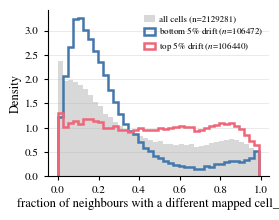

[save_fig] wrote figures_for_paper/drift_group_distributions_expr_cosine_dist_to_neighbors_step.{png,pdf}


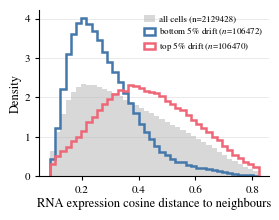

In [93]:
if analysis_df is not None:
    top_mask, bottom_mask = top_bottom_drift_masks(analysis_df)
    print(f"top-drift: n={int(top_mask.sum())}, bottom-drift: n={int(bottom_mask.sum())} "
          f"(top/bottom {TOP_BOTTOM_DRIFT_FRAC:.0%} of {int(np.isfinite(analysis_df['drift']).sum())} cells with a drift value)")

    for value_col, xlabel in [("heterotypic_frac", "fraction of neighbours with a different mapped cell_type"),
                              ("expr_cosine_dist_to_neighbors", RNA_CONTEXT_DIVERGENCE_XLABEL)]:
        plot_group_distributions_with_all(
            analysis_df, value_col, xlabel, top_mask, bottom_mask,
            f"top {TOP_BOTTOM_DRIFT_FRAC:.0%} drift", f"bottom {TOP_BOTTOM_DRIFT_FRAC:.0%} drift",
        )
else:
    print("[skip] analysis_df is None -- see the cell above.")


### RNA-context divergence: figure style variants (for review -- pick one for the paper)

Three ways to draw the same distributions (this plot and the masking-disagreement
plot in section 10, since both will sit side by side in the paper). All three keep
the settled choices -- blue/red, the shared x-axis label, stats folded into the
legend, no title -- and only vary how each group's distribution is drawn:

- **A -- step outline** (the default above): each group as an unfilled step
  histogram outline.
- **B -- filled**: semi-transparent filled histograms.
- **C -- smoothed density (KDE)**: kernel density estimate curves instead of
  histogram bars.

Re-run a cell to view that style; once you've picked one, tell me which and I'll
fold it into the two canonical plotting functions (and the matching section-10
variant below) and drop the rest.


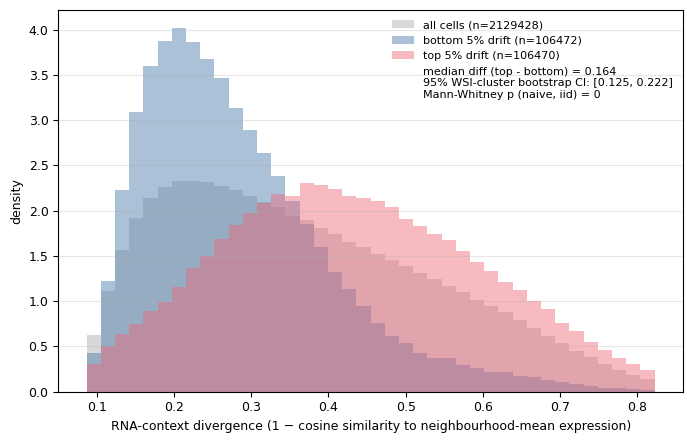

In [21]:
# Variant: filled histograms
if analysis_df is not None:
    plot_group_distributions_with_all(
        analysis_df, "expr_cosine_dist_to_neighbors", RNA_CONTEXT_DIVERGENCE_XLABEL, top_mask, bottom_mask,
        f"top {TOP_BOTTOM_DRIFT_FRAC:.0%} drift", f"bottom {TOP_BOTTOM_DRIFT_FRAC:.0%} drift",
        style="filled",
    )
else:
    print("[skip] analysis_df is None -- see the cells above.")


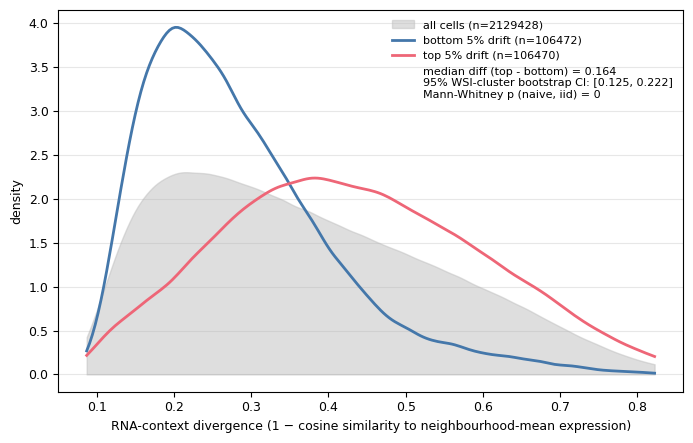

In [22]:
# Variant: smoothed density (KDE)
if analysis_df is not None:
    plot_group_distributions_with_all(
        analysis_df, "expr_cosine_dist_to_neighbors", RNA_CONTEXT_DIVERGENCE_XLABEL, top_mask, bottom_mask,
        f"top {TOP_BOTTOM_DRIFT_FRAC:.0%} drift", f"bottom {TOP_BOTTOM_DRIFT_FRAC:.0%} drift",
        style="kde",
    )
else:
    print("[skip] analysis_df is None -- see the cells above.")


## 10. RNA-context divergence vs. masking disagreement: distributions

From `saved_cells_deep_dive.ipynb`'s §8 ("RNA expression vs. context, for the
masking disagreement set"): for cells correct under both Phikon-v2 masked and
unmasked ("correct in both") vs. cells correct unmasked but wrong when masked
("correct unmasked, wrong masked"), cosine distance between each cell's
log1p-normalized Xenium expression and the mean expression of its `k=30` nearest
spatial neighbours. **Enhanced here**: overlaid distributions for the two groups
(instead of a plain boxplot) plus both the original Mann-Whitney test *and* a
WSI-cluster bootstrap (same test as section 9) annotated on the plot -- cells
within a WSI aren't independent draws, so the cluster bootstrap is the more
defensible of the two; Mann-Whitney is kept only as the original reference point.

Uses `PhikonV2_448` / `PhikonV2_448_masked` `test_predictions.csv`, read via
`MASK_TOKEN` (`nucleus`) -- the segment both colon runs were actually saved
under, matching sections 6 and 7 and the original notebook this was copied from.

In [83]:
import scanpy as sc  # noqa: E402
from matplotlib.lines import Line2D  # noqa: E402

RNA_DIVERGENCE_EMBEDDINGS = MASK_TOKEN  # "nucleus" -- the segment both Phikon-v2 colon runs were saved under
RNA_DIVERGENCE_K_NEIGHBORS = 30


def align_conditions(df_a: pd.DataFrame, df_b: pd.DataFrame, label_a: str, label_b: str) -> pd.DataFrame:
    keep = ["cell_id", "wsi", "true_label", "predicted_label", "correct"]
    a = df_a[keep].rename(columns={c: f"{c}__{label_a}" for c in keep if c not in ("cell_id", "wsi")})
    b = df_b[keep].rename(columns={c: f"{c}__{label_b}" for c in keep if c not in ("cell_id", "wsi")})
    merged = a.merge(b, on=["cell_id", "wsi"], how="inner")
    assert (merged[f"true_label__{label_a}"] == merged[f"true_label__{label_b}"]).all(), \
        "true_label disagrees between conditions for a shared cell_id -- check both used the same mapping"
    merged["true_label"] = merged[f"true_label__{label_a}"]
    correct_a, correct_b = merged[f"correct__{label_a}"], merged[f"correct__{label_b}"]
    merged["quadrant"] = np.select(
        [correct_a & correct_b, (~correct_a) & (~correct_b), correct_a & (~correct_b), (~correct_a) & correct_b],
        ["both_correct", "both_wrong", f"{label_a}_only_correct", f"{label_b}_only_correct"],
    )
    return merged


_ADATA_LOGNORM_CACHE: dict[str, "ad.AnnData"] = {}


def load_adata_lognorm(wsi: str) -> "ad.AnnData":
    if wsi not in _ADATA_LOGNORM_CACHE:
        path = P.XENIUM_PROCESSED_OUTPUT_ROOT / wsi / "adata.h5ad"
        adata = ad.read_h5ad(path)
        adata.X = adata.layers["counts"].copy()
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        _ADATA_LOGNORM_CACHE[wsi] = adata
    return _ADATA_LOGNORM_CACHE[wsi]


def rna_context_divergence(wsi: str, k_neighbors: int = RNA_DIVERGENCE_K_NEIGHBORS) -> pd.DataFrame:
    adata = load_adata_lognorm(wsi)
    coords = get_patch_coordinates(wsi).set_index("cell_id")
    common = coords.index.intersection(adata.obs.index)
    if len(common) < k_neighbors + 1:
        return pd.DataFrame(columns=["divergence"])
    barcode_to_row = {b: i for i, b in enumerate(adata.obs.index.values)}
    rows = [barcode_to_row[c] for c in common]
    X = adata.X[rows]
    X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
    xy = coords.loc[common, ["x_centroid_px", "y_centroid_px"]].values
    tree = cKDTree(xy)
    _, idx = tree.query(xy, k=k_neighbors + 1)
    neighbor_mean = X[idx[:, 1:]].mean(axis=1)
    own_norm = np.linalg.norm(X, axis=1)
    neigh_norm = np.linalg.norm(neighbor_mean, axis=1)
    denom = own_norm * neigh_norm
    cos_sim = np.divide((X * neighbor_mean).sum(axis=1), denom,
                         out=np.full(len(common), np.nan), where=denom > 0)
    return pd.DataFrame({"divergence": 1 - cos_sim}, index=pd.Index(common, name="cell_id"))


def attach_rna_divergence(df: pd.DataFrame, k_neighbors: int = RNA_DIVERGENCE_K_NEIGHBORS) -> pd.DataFrame:
    if df.empty:
        return df
    out = []
    for wsi, group in df.groupby("wsi"):
        div = rna_context_divergence(wsi, k_neighbors)
        out.append(group.join(div, on="cell_id"))
    return pd.concat(out, ignore_index=True)


def plot_two_group_distributions(group_a: np.ndarray, group_b: np.ndarray,
                                 label_a: str, label_b: str, xlabel: str,
                                 groups_for_bootstrap: np.ndarray = None, bins: int = 40,
                                 all_values: np.ndarray = None, all_label: str = "all cells",
                                 style: str = "step", show_stats: bool = False) -> dict:
    pooled = np.concatenate([group_a, group_b])
    ref = all_values if all_values is not None and len(all_values) else pooled
    lo, hi = np.percentile(ref, [0.5, 99.5])
    edges = np.linspace(lo, hi, bins + 1)

    fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))

    if all_values is not None and len(all_values):
        draw_all_cells_distribution(ax, all_values, edges, style, all_label)
    draw_group_distribution(ax, group_b, edges, COLOR_BLUE, f"{label_b} ($n$={len(group_b)})", style)
    draw_group_distribution(ax, group_a, edges, COLOR_RED,  f"{label_a} ($n$={len(group_a)})", style)

    ax.set_xlabel(xlabel, labelpad=2)
    ax.set_ylabel("Density", labelpad=2)

    _, mw_p = mannwhitneyu(group_a, group_b, alternative="two-sided")
    stats = {"mannwhitney_p": float(mw_p)}
    if groups_for_bootstrap is not None:
        mask_a = np.concatenate([np.ones(len(group_a), dtype=bool),
                                 np.zeros(len(group_b), dtype=bool)])
        mask_b = ~mask_a
        boot = cluster_bootstrap_group_diff(pooled, mask_a, mask_b, groups_for_bootstrap)
        stats.update(median_diff=float(boot["median_diff"]),
                     ci_lo=float(boot["ci_lo"]), ci_hi=float(boot["ci_hi"]))

    ax.legend(fontsize=6.5, frameon=False, loc="upper right",
              handlelength=1.2, handletextpad=0.5, labelspacing=0.25,
              borderaxespad=0.2)

    if show_stats:  # notebook use only; keep it out of the paper figure
        txt = f"$p$ = {mw_p:.2g}"
        if "median_diff" in stats:
            txt = (f"$\\Delta$median = {stats['median_diff']:.3g}\n"
                   f"95% CI [{stats['ci_lo']:.3g}, {stats['ci_hi']:.3g}]\n" + txt)
        ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
                fontsize=6, color="0.25")

    ax.grid(axis="y", alpha=0.3, linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout(pad=0.2)
    save_fig(fig, f"rna_divergence_broken_by_masking_distributions_{style}")
    plt.show()
    return stats

[save_fig] wrote figures_for_paper/rna_divergence_broken_by_masking_distributions_step.{png,pdf}


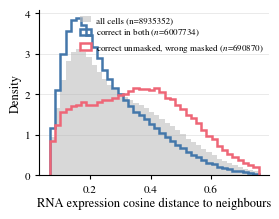

In [91]:
_masked_preds = load_test_predictions(CLASSIFIER_ROOTS["colon"], MASK_COMPARISON["masked"], RNA_DIVERGENCE_EMBEDDINGS)
_unmasked_preds = load_test_predictions(CLASSIFIER_ROOTS["colon"], MASK_COMPARISON["unmasked"], RNA_DIVERGENCE_EMBEDDINGS)

if not _masked_preds.empty and not _unmasked_preds.empty:
    unmasked_div = attach_rna_divergence(_unmasked_preds)
    aligned_mask_div = align_conditions(unmasked_div, _masked_preds, "unmasked", "masked").merge(
        unmasked_div[["cell_id", "wsi", "divergence"]], on=["cell_id", "wsi"], how="left"
    )
    both_correct = aligned_mask_div.loc[aligned_mask_div["quadrant"] == "both_correct", ["divergence", "wsi"]].dropna()
    broken_by_masking = aligned_mask_div.loc[aligned_mask_div["quadrant"] == "unmasked_only_correct", ["divergence", "wsi"]].dropna()
    all_div = aligned_mask_div["divergence"].dropna().to_numpy()

    if len(both_correct) > 5 and len(broken_by_masking) > 5:
        pooled_wsi = pd.concat([both_correct["wsi"], broken_by_masking["wsi"]]).to_numpy()
        plot_two_group_distributions(
            broken_by_masking["divergence"].to_numpy(), both_correct["divergence"].to_numpy(),
            "correct unmasked, wrong masked", "correct in both",
            RNA_CONTEXT_DIVERGENCE_XLABEL,
            groups_for_bootstrap=pooled_wsi,
            all_values=all_div, all_label="all cells",
        )
    else:
        print(f"[skip] too few cells in one group (both_correct n={len(both_correct)}, "
              f"broken_by_masking n={len(broken_by_masking)})")
else:
    print("[skip] masked/unmasked PhikonV2 test_predictions not both loaded -- see [missing] above.")


### RNA-context divergence (masking-disagreement): style variants (for review)

Same plot as above (default style, `"step"`), in two more styles -- see the section 9
variants below for what each one means. Uses the `broken_by_masking` / `both_correct` /
`all_div` computed in the cell above, so it's cheap to re-run.


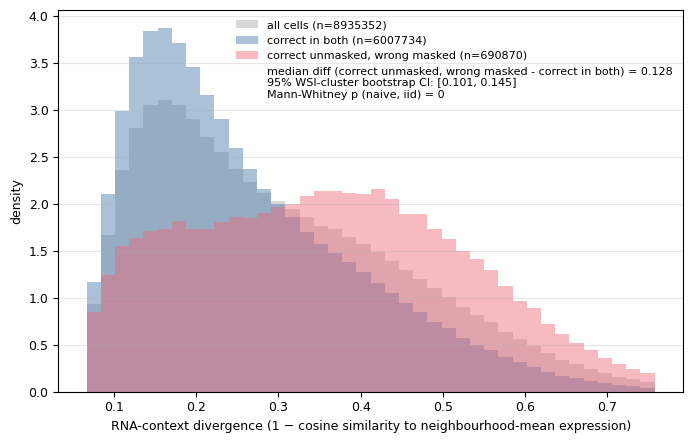

In [25]:
# Variant: filled histograms
if not _masked_preds.empty and not _unmasked_preds.empty and len(both_correct) > 5 and len(broken_by_masking) > 5:
    plot_two_group_distributions(
        broken_by_masking["divergence"].to_numpy(), both_correct["divergence"].to_numpy(),
        "correct unmasked, wrong masked", "correct in both",
        RNA_CONTEXT_DIVERGENCE_XLABEL,
        groups_for_bootstrap=pooled_wsi,
        all_values=all_div, all_label="all cells",
        style="filled",
    )
else:
    print("[skip] see the cell above.")


KeyboardInterrupt: 

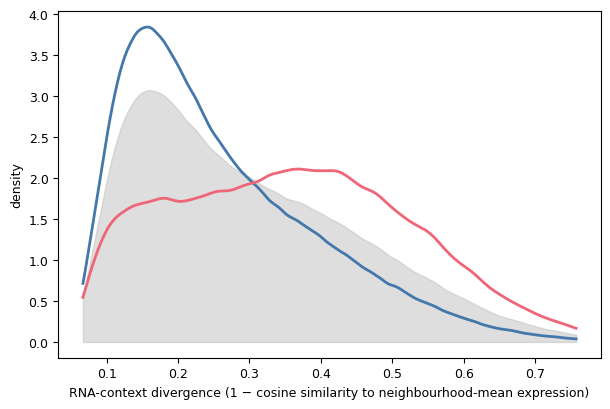

In [26]:
# Variant: smoothed density (KDE)
if not _masked_preds.empty and not _unmasked_preds.empty and len(both_correct) > 5 and len(broken_by_masking) > 5:
    plot_two_group_distributions(
        broken_by_masking["divergence"].to_numpy(), both_correct["divergence"].to_numpy(),
        "correct unmasked, wrong masked", "correct in both",
        RNA_CONTEXT_DIVERGENCE_XLABEL,
        groups_for_bootstrap=pooled_wsi,
        all_values=all_div, all_label="all cells",
        style="kde",
    )
else:
    print("[skip] see the cell above.")


## 11. Multicell UNI2 (colon): performance vs. forward passes / reduction factor

`UNI2_448_112_multicell` / `UNI2_448_224_multicell` / `UNI2_448_448_multicell`
(one per central-window size -- see `README.md`'s `central_size_x`/`central_size_y`),
read via `cell_token` (multicell's single per-cell token, no CLS/corner split),
macro-F1 on the colon classification task. Dashed line = the CLS baseline
(`UNI2 | cls`, i.e. `UNI2_NATIVE`, plain per-cell UNI2).

**`FORWARD_PASSES` in CONFIG has `None` placeholders** -- fill in the real
per-model forward-pass counts there (including the plain per-cell UNI2 baseline,
needed as the reduction-factor denominator: `reduction_factor =
FORWARD_PASSES[CLS_BASELINE_MODEL] / FORWARD_PASSES[model]`) before running this
section; rows with a missing count are skipped from the x=forward-passes /
x=reduction-factor plots (but still shown in the table) and reported below.

[colon] expected 8 LOSO splits per condition; CLS baseline macro-F1 = 0.5823 ± 0.1084


,model,model_name,num_forward_passes,reduction_factor,macro_f1_mean,macro_f1_std,n_splits,gain_over_cls_baseline_mean,gain_over_cls_baseline_std,gain_n_splits
0,UNI2 multicell (112px window),UNI2_448_112_multicell,200830,6.4061,0.6747,0.0992,7,0.0981,0.0334,7
1,UNI2 multicell (224px window),UNI2_448_224_multicell,63340,20.3117,0.6750,0.0920,8,0.0927,0.0335,8
2,UNI2 multicell (448px window),UNI2_448_448_multicell,18450,69.7313,0.6694,0.0900,8,0.0870,0.0359,8


\begin{table}
\caption{multicell uni2 colon}
\label{tab:multicell_uni2_colon}
\begin{tabular}{llrrrrrrrr}
\toprule
model & model_name & num_forward_passes & reduction_factor & macro_f1_mean & macro_f1_std & n_splits & gain_over_cls_baseline_mean & gain_over_cls_baseline_std & gain_n_splits \\
\midrule
UNI2 multicell (112px window) & UNI2_448_112_multicell & 200830 & 6.4061 & 0.6747 & 0.0992 & 7 & 0.0981 & 0.0334 & 7 \\
UNI2 multicell (224px window) & UNI2_448_224_multicell & 63340 & 20.3117 & 0.6750 & 0.0920 & 8 & 0.0927 & 0.0335 & 8 \\
UNI2 multicell (448px window) & UNI2_448_448_multicell & 18450 & 69.7313 & 0.6694 & 0.0900 & 8 & 0.0870 & 0.0359 & 8 \\
\bottomrule
\end{tabular}
\end{table}



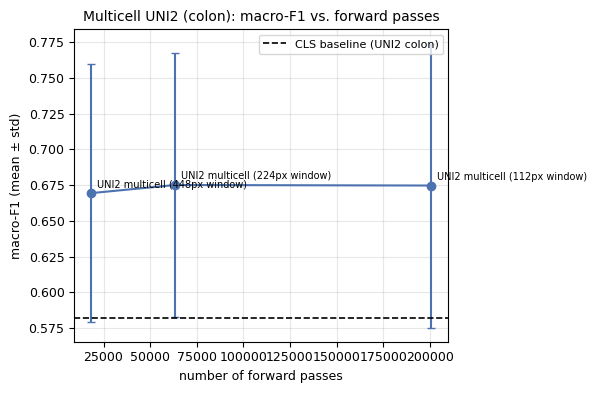

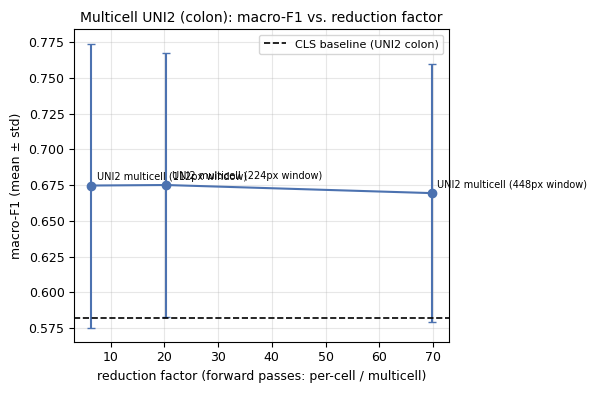

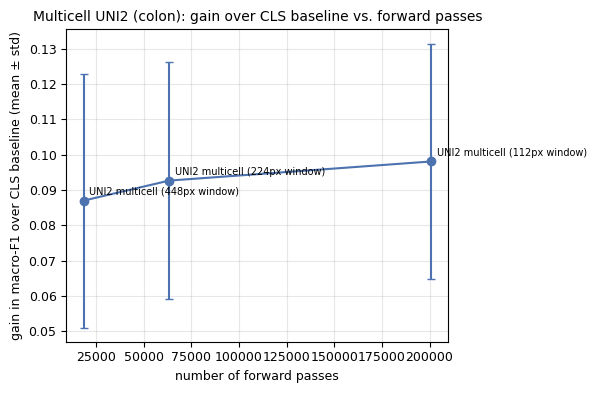

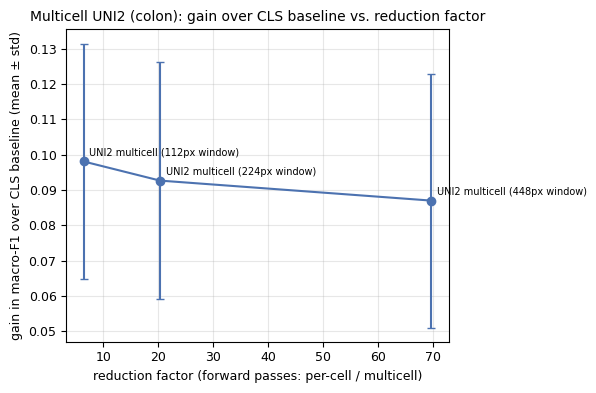

In [61]:
def build_multicell_table(dataset: str = "colon", token: str = MULTICELL_TOKEN):
    baseline_fp = FORWARD_PASSES.get(CLS_BASELINE_MODEL)
    baseline_f1_mean, baseline_f1_std, baseline_f1_n = mean_std_n(CLASSIFIER_DF, dataset, CLS_BASELINE_MODEL, TOKEN_CLS)
    rows = []
    for model in MULTICELL_MODELS:
        fp = FORWARD_PASSES.get(model)
        m, s, n = mean_std_n(CLASSIFIER_DF, dataset, model, token)
        gain_m, gain_s, gain_n = paired_diff(CLASSIFIER_DF, dataset, model, token, CLS_BASELINE_MODEL, TOKEN_CLS)
        reduction = (baseline_fp / fp) if (baseline_fp and fp) else np.nan
        rows.append({"model": MODEL_LABELS.get(model, model), "model_name": model,
                     "num_forward_passes": fp, "reduction_factor": reduction,
                     "macro_f1_mean": m, "macro_f1_std": s, "n_splits": n,
                     "gain_over_cls_baseline_mean": gain_m, "gain_over_cls_baseline_std": gain_s,
                     "gain_n_splits": gain_n})
    df = pd.DataFrame(rows)
    _missing_fp = [m for m in MULTICELL_MODELS + [CLS_BASELINE_MODEL] if FORWARD_PASSES.get(m) is None]
    if _missing_fp:
        print(f"[warning] FORWARD_PASSES missing for: {_missing_fp} -- fill these in in CONFIG. "
              f"num_forward_passes/reduction_factor plots will skip the affected rows.")
    print(f"[colon] expected {EXPECTED_SPLITS['colon']} LOSO splits per condition; "
          f"CLS baseline macro-F1 = {fmt_mean_std(baseline_f1_mean, baseline_f1_std, baseline_f1_n, EXPECTED_SPLITS['colon'])}")
    return df, baseline_f1_mean


_multicell_df, _cls_baseline_f1 = build_multicell_table()
show_table(_multicell_df.round(4), "multicell_uni2_colon")


def plot_multicell(df: pd.DataFrame, x_col: str, y_mean_col: str, y_std_col: str,
                    xlabel: str, ylabel: str, title: str, baseline: float = None, baseline_label: str = "") -> None:
    plot_df = df.dropna(subset=[x_col, y_mean_col])
    if plot_df.empty:
        print(f"[skip plot] no rows with both {x_col!r} and {y_mean_col!r} available.")
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    order = plot_df[x_col].argsort()
    ax.errorbar(plot_df[x_col].to_numpy()[order], plot_df[y_mean_col].to_numpy()[order],
                yerr=plot_df[y_std_col].to_numpy()[order], marker="o", capsize=3, color="#4C72B0")
    for _, row in plot_df.iterrows():
        ax.annotate(row["model"], (row[x_col], row[y_mean_col]), fontsize=7, textcoords="offset points", xytext=(4, 4))
    if baseline is not None and np.isfinite(baseline):
        ax.axhline(baseline, color="black", linestyle="--", linewidth=1.2, label=baseline_label)
        ax.legend(fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    save_fig(fig, title.lower().replace(" ", "_").replace("/", "_"))
    plt.show()


plot_multicell(_multicell_df, "num_forward_passes", "macro_f1_mean", "macro_f1_std",
               "number of forward passes", "macro-F1 (mean \u00b1 std)",
               "Multicell UNI2 (colon): macro-F1 vs. forward passes",
               baseline=_cls_baseline_f1, baseline_label="CLS baseline (UNI2 colon)")

plot_multicell(_multicell_df, "reduction_factor", "macro_f1_mean", "macro_f1_std",
               "reduction factor (forward passes: per-cell / multicell)", "macro-F1 (mean \u00b1 std)",
               "Multicell UNI2 (colon): macro-F1 vs. reduction factor",
               baseline=_cls_baseline_f1, baseline_label="CLS baseline (UNI2 colon)")

plot_multicell(_multicell_df, "num_forward_passes", "gain_over_cls_baseline_mean", "gain_over_cls_baseline_std",
               "number of forward passes", "gain in macro-F1 over CLS baseline (mean \u00b1 std)",
               "Multicell UNI2 (colon): gain over CLS baseline vs. forward passes")

plot_multicell(_multicell_df, "reduction_factor", "gain_over_cls_baseline_mean", "gain_over_cls_baseline_std",
               "reduction factor (forward passes: per-cell / multicell)", "gain in macro-F1 over CLS baseline (mean \u00b1 std)",
               "Multicell UNI2 (colon): gain over CLS baseline vs. reduction factor")


### Multicell vs. monocell UNI2 (colon)

The 3 multicell models above vs. 4 "monocell" (one forward pass per cell) UNI2
points: `UNI2_448_resized` read via `nucleus` and via `cls`, and `UNI2_100_resized`
read via `cls` and via `central` (the 4-corner average) -- `MULTICELL_VS_MONOCELL_POINTS`
in CONFIG. Colour marks the crop-then-resize-to-224 field of view (448px = blue,
100px = red); marker shape marks the token read out (CLS = star, central/nucleus =
circle, multicell = square). x-axis is log-scaled -- forward-pass counts span two
orders of magnitude (multicell: {18450, 63340, 200830}; monocell: 1 pass/cell for
every one of the 4 monocell points, i.e. `FORWARD_PASSES[CLS_BASELINE_MODEL]`, so
they all sit at the same x and are told apart only by colour/marker/y).

Two plots: macro-F1 vs. forward passes (dashed line = the CLS baseline, as in the
plots above), and improvement over that same CLS baseline vs. forward passes
(dashed line at 0 = no improvement).


[colon] expected 8 LOSO splits per condition; monocell x = 1286543 forward passes (1/cell, same as UNI2 | cls).


,label,model_name,embeddings,family,marker,num_forward_passes,macro_f1_mean,macro_f1_std,n_splits,improvement_over_baseline_mean,improvement_over_baseline_std,improvement_n_splits
0,multicell 112px window,UNI2_448_112_multicell,nucleus,448,s,200830,0.6747,0.0992,7,0.0981,0.0334,7
1,multicell 224px window,UNI2_448_224_multicell,nucleus,448,s,63340,0.6750,0.0920,8,0.0927,0.0335,8
2,multicell 448px window,UNI2_448_448_multicell,nucleus,448,s,18450,0.6694,0.0900,8,0.0870,0.0359,8
3,"448px resized, nucleus",UNI2_448_resized,nucleus,448,o,1286543,0.6870,0.0961,8,0.1046,0.0352,8
4,"448px resized, CLS",UNI2_448_resized,cls,448,*,1286543,0.5445,0.1450,8,-0.0378,0.0382,8
5,"100px resized, CLS",UNI2_100_resized,cls,100,*,1286543,0.5419,0.1062,8,-0.0404,0.0274,8
6,"100px resized, central",UNI2_100_resized,bottom_left_bottom_right_top_left_top_right,100,o,1286543,0.6081,0.0904,8,0.0257,0.0518,8
7,"224px native, CLS (baseline)",UNI2,cls,224,*,1286543,0.5823,0.1084,8,0.0000,0.0000,8
8,"224px native, central",UNI2,bottom_left_bottom_right_top_left_top_right,224,o,1286543,0.6836,0.0987,8,0.1013,0.0383,8


\begin{table}
\caption{multicell vs monocell uni2 colon}
\label{tab:multicell_vs_monocell_uni2_colon}
\begin{tabular}{lllllrrrrrrr}
\toprule
label & model_name & embeddings & family & marker & num_forward_passes & macro_f1_mean & macro_f1_std & n_splits & improvement_over_baseline_mean & improvement_over_baseline_std & improvement_n_splits \\
\midrule
multicell 112px window & UNI2_448_112_multicell & nucleus & 448 & s & 200830 & 0.6747 & 0.0992 & 7 & 0.0981 & 0.0334 & 7 \\
multicell 224px window & UNI2_448_224_multicell & nucleus & 448 & s & 63340 & 0.6750 & 0.0920 & 8 & 0.0927 & 0.0335 & 8 \\
multicell 448px window & UNI2_448_448_multicell & nucleus & 448 & s & 18450 & 0.6694 & 0.0900 & 8 & 0.0870 & 0.0359 & 8 \\
448px resized, nucleus & UNI2_448_resized & nucleus & 448 & o & 1286543 & 0.6870 & 0.0961 & 8 & 0.1046 & 0.0352 & 8 \\
448px resized, CLS & UNI2_448_resized & cls & 448 & * & 1286543 & 0.5445 & 0.1450 & 8 & -0.0378 & 0.0382 & 8 \\
100px resized, CLS & UNI2_100_resized & cls &

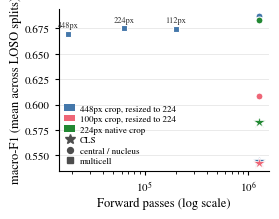

[save_fig] wrote figures_for_paper/uni2_colon_multicell_vs._monocell_improvement_over_baseline_vs._forward_passes_points.{png,pdf}


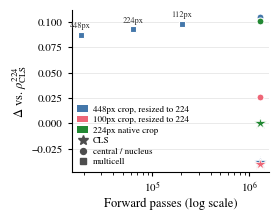

In [86]:
from matplotlib.lines import Line2D  # noqa: E402
from matplotlib.patches import Patch  # noqa: E402



def build_multicell_vs_monocell_table(dataset: str = "colon",
                                       points: list[tuple[str, str, str, str, str]] = MULTICELL_VS_MONOCELL_POINTS):
    """One row per MULTICELL_VS_MONOCELL_POINTS entry -- see CONFIG for why every
    non-multicell ("monocell") point shares FORWARD_PASSES[CLS_BASELINE_MODEL] as x."""
    monocell_fp = FORWARD_PASSES.get(CLS_BASELINE_MODEL)
    rows = []
    for label, model, embeddings, family, marker in points:
        fp = FORWARD_PASSES.get(model) if model in MULTICELL_MODELS else monocell_fp
        m, s, n = mean_std_n(CLASSIFIER_DF, dataset, model, embeddings)
        gain_m, gain_s, gain_n = paired_diff(CLASSIFIER_DF, dataset, model, embeddings, CLS_BASELINE_MODEL, TOKEN_CLS)
        rows.append({
            "label": label, "model_name": model, "embeddings": embeddings, "family": family, "marker": marker,
            "num_forward_passes": fp,
            "macro_f1_mean": m, "macro_f1_std": s, "n_splits": n,
            "improvement_over_baseline_mean": gain_m, "improvement_over_baseline_std": gain_s,
            "improvement_n_splits": gain_n,
        })
    df = pd.DataFrame(rows)
    _missing_fp = df.loc[df["num_forward_passes"].isna(), "label"].tolist()
    if _missing_fp:
        print(f"[warning] FORWARD_PASSES missing a count for: {_missing_fp} -- these rows are dropped from the plots below.")
    for col in ("n_splits", "improvement_n_splits"):
        n_missing = (df[col] == 0).sum()
        if n_missing:
            print(f"[colon] {n_missing}/{len(df)} point(s) have 0 splits for column {col!r} -- see table below.")
    print(f"[colon] expected {EXPECTED_SPLITS['colon']} LOSO splits per condition; "
          f"monocell x = {monocell_fp} forward passes (1/cell, same as {CLS_BASELINE_MODEL} | {TOKEN_CLS}).")
    return df


_mc_vs_monocell_df = build_multicell_vs_monocell_table()
show_table(_mc_vs_monocell_df.round(4), "multicell_vs_monocell_uni2_colon")

MARKER_SIZE_SCALE = {
    "o": 1.00, "s": 0.95, "D": 1.15, "v": 1.20,
    "^": 1.20, "*": 1.75, "P": 1.25, "X": 1.25, "x": 1.35, "+": 1.40,
}
BASE_MS = 5.0

def _ms(marker):
    return BASE_MS * MARKER_SIZE_SCALE.get(marker, 1.0)

def plot_multicell_vs_monocell(df: pd.DataFrame, y_mean_col: str, ylabel: str, title: str,
                               style: str = "points") -> None:
    plot_df = df.dropna(subset=["num_forward_passes", y_mean_col])
    if plot_df.empty:
        print(f"[skip plot] no rows with both num_forward_passes and {y_mean_col!r} available.")
        return

    fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))

    if style == "connected":
        for family, group in plot_df.groupby("family"):
            group = group.sort_values("num_forward_passes")
            ax.plot(group["num_forward_passes"], group[y_mean_col], linestyle="--",
                    linewidth=1.0, color=MULTICELL_VS_MONOCELL_COLORS[family], zorder=2)

    for _, row in plot_df.iterrows():
        mk = row["marker"]
        ax.plot(row["num_forward_passes"], row[y_mean_col],
                marker=mk, markersize=_ms(mk),
                markeredgecolor="white",
                markeredgewidth=0.5 if mk in ("*", "x", "+", "^", "v") else 0.8,
                color=MULTICELL_VS_MONOCELL_COLORS[row["family"]],
                linestyle="none", zorder=3)
        window_px = MULTICELL_WINDOW_PX.get(row["model_name"])
        if window_px is not None:
            ax.annotate(f"{window_px}px", xy=(row["num_forward_passes"], row[y_mean_col]),
                        xytext=(0, 5), textcoords="offset points", ha="center",
                        fontsize=6, color="0.2")
        elif style == "labeled":
            ax.annotate(row["label"], xy=(row["num_forward_passes"], row[y_mean_col]),
                        xytext=(4, 3), textcoords="offset points", fontsize=5.5, color="0.2")

    family_handles = [Patch(facecolor=MULTICELL_VS_MONOCELL_COLORS[fov], label=lbl)
                      for fov, lbl in MULTICELL_VS_MONOCELL_FAMILY_LABELS.items()]
    marker_handles = [Line2D([0], [0], marker=mk, color="0.3", linestyle="none",
                             markersize=_ms(mk) * 0.85, label=lbl)
                      for mk, lbl in MULTICELL_VS_MONOCELL_MARKER_LABELS.items()]
    ax.legend(handles=family_handles + marker_handles, loc="lower left",
              frameon=False, handlelength=1.2, handletextpad=0.5,
              labelspacing=0.25, borderaxespad=0.2)

    ax.set_xscale("log")
    ax.set_xlabel("Forward passes (log scale)", labelpad=2)
    ax.set_ylabel(ylabel, labelpad=2)
    ax.grid(axis="y", alpha=0.3, linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout(pad=0.2)
    save_fig(fig, title.lower().replace(" ", "_").replace("/", "_")
                       .replace(",", "").replace(":", "") + f"_{style}")
    plt.show()


plot_multicell_vs_monocell(
    _mc_vs_monocell_df, "macro_f1_mean", "macro-F1 (mean across LOSO splits)",
    "UNI2 colon: multicell vs. monocell, macro-F1 vs. forward passes",
)

plot_multicell_vs_monocell(
    _mc_vs_monocell_df, "improvement_over_baseline_mean", r"$\Delta$ vs. $\rho_{\mathrm{CLS}}^{224}$",
    "UNI2 colon: multicell vs. monocell, improvement over baseline vs. forward passes",
)


### Multicell vs. monocell: figure style variants (for review -- pick one for the paper)

Same two plots as above (default style, `"points"`), in two more styles, so a look
can be picked before finalizing:

- **connected**: adds a thin dashed line connecting the 3 multicell points and the
  per-family monocell points (blue = 448px family, red = 100px family), sorted by
  forward-pass count, to show the trend within each field-of-view family.
- **labeled**: keeps plain markers but adds a small direct text label next to every
  point (its `label` from `MULTICELL_VS_MONOCELL_POINTS`), so a point's identity is
  readable without cross-referencing the legend.

Re-run either cell to view that style; once you've picked one (or keep `"points"`,
the default above), tell me which and I'll fold it into the two canonical calls and
drop the others.


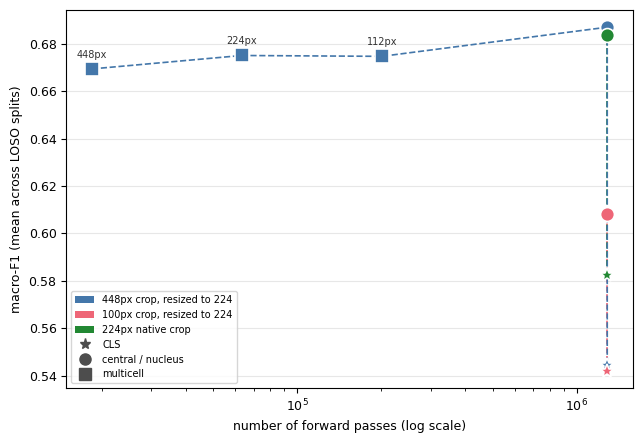

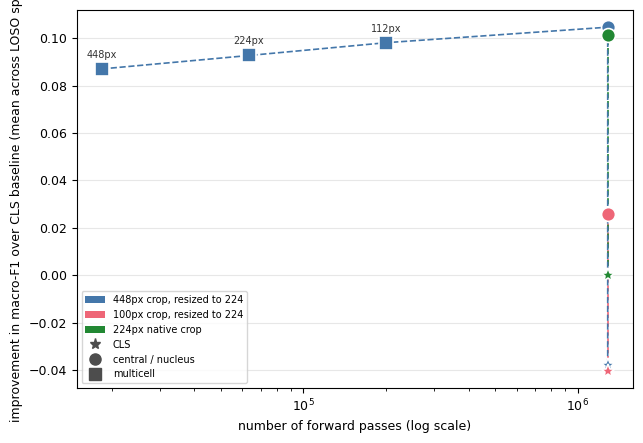

In [68]:
# Variant: connected -- dashed trend line per family
plot_multicell_vs_monocell(
    _mc_vs_monocell_df, "macro_f1_mean", "macro-F1 (mean across LOSO splits)",
    "UNI2 colon: multicell vs. monocell, macro-F1 vs. forward passes",
    style="connected",
)

plot_multicell_vs_monocell(
    _mc_vs_monocell_df, "improvement_over_baseline_mean", "improvement in macro-F1 over CLS baseline (mean across LOSO splits)",
    "UNI2 colon: multicell vs. monocell, improvement over baseline vs. forward passes",
    style="connected",
)


[save_fig] wrote figures_for_paper/uni2_colon_multicell_vs._monocell_macro-f1_vs._forward_passes_labeled.{png,pdf}


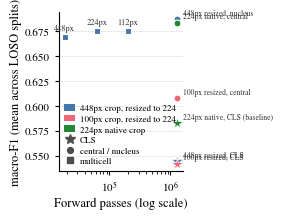

[save_fig] wrote figures_for_paper/uni2_colon_multicell_vs._monocell_improvement_over_baseline_vs._forward_passes_labeled.{png,pdf}


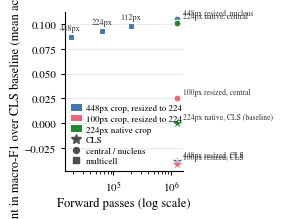

In [87]:
# Variant: labeled -- direct text label on every point
plot_multicell_vs_monocell(
    _mc_vs_monocell_df, "macro_f1_mean", "macro-F1 (mean across LOSO splits)",
    "UNI2 colon: multicell vs. monocell, macro-F1 vs. forward passes",
    style="labeled",
)

plot_multicell_vs_monocell(
    _mc_vs_monocell_df, "improvement_over_baseline_mean", "improvement in macro-F1 over CLS baseline (mean across LOSO splits)",
    "UNI2 colon: multicell vs. monocell, improvement over baseline vs. forward passes",
    style="labeled",
)


## 12. DeepSpot colon: UNI2 vs. UNI2 (resized), fold-change vs. 30 neighbours

`outputs_deepspot_colon`: `UNI2_specific_tokens_folder` ("UNI2", `UNI2_NATIVE_DEEPSPOT`
-- this root still uses the old folder name) vs. `UNI2_56_resized` ("UNI2 resized"),
across `num_neighbours` ∈ {30, 15, 0} -- fold-change (and % decrease) in performance
relative to each model's own 30-neighbour point.

The fold change is computed **per LOSO split** (each split's value divided by that
same split's 30-neighbour value), then reported as mean ± std across splits, so it
carries a spread like every other comparison in this notebook. `fold_change_n_splits`
is how many splits were matched on both sides; if none are (0 splits), the table
falls back to the ratio of the two means and reports a `NaN` std.

Metric auto-picked from whatever `*pearson*` column `load_deepspot_results` found in
`results_summary.yaml` (printed above when `DEEPSPOT_DF` was loaded) -- set
`DEEPSPOT_METRIC` below if the auto-pick is wrong.

In [70]:
DEEPSPOT_METRIC = None  # None = auto-pick a "*mean*pearson*" column, else the first pearson-like column found


def build_deepspot_foldchange_table(df: pd.DataFrame = DEEPSPOT_DF, metric: str = DEEPSPOT_METRIC):
    if df.empty:
        print("[empty] DEEPSPOT_DF is empty -- nothing to compute.")
        return pd.DataFrame()
    pearson_cols = [c for c in df.columns if "pearson" in c.lower()]
    if not pearson_cols:
        print("[warning] no pearson-like column found in results_summary.yaml -- check the actual key names there.")
        return pd.DataFrame()
    metric = metric or next((c for c in pearson_cols if "mean" in c.lower()), pearson_cols[0])
    print(f"[using metric] {metric!r} (available: {pearson_cols})")

    rows = []
    for label, model in DEEPSPOT_MODELS.items():
        sub_model = df[df["model_name"] == model]
        base = sub_model.loc[sub_model["num_neighbours"] == 30, ["split_idx", metric]].dropna()
        base_mean = base[metric].mean() if len(base) else np.nan
        for n_neighbours in DEEPSPOT_NEIGHBOURS:
            cur = sub_model.loc[sub_model["num_neighbours"] == n_neighbours, ["split_idx", metric]].dropna()
            mean_v = cur[metric].mean() if len(cur) else np.nan
            std_v = cur[metric].std() if len(cur) > 1 else 0.0

            # Fold change per LOSO split (paired on split_idx, like every other diff in this
            # notebook), then mean +/- std across the matched splits -- not a ratio of means,
            # so it comes with a spread. Falls back to the ratio of means (std = NaN) if no
            # split is present on both sides.
            paired = cur.merge(base, on="split_idx", suffixes=("_cur", "_base"))
            ratios = (paired[f"{metric}_cur"] / paired[f"{metric}_base"]).replace([np.inf, -np.inf], np.nan).dropna()
            if len(ratios):
                fold_change = float(ratios.mean())
                fold_change_std = float(ratios.std()) if len(ratios) > 1 else 0.0
            else:
                fold_change = (mean_v / base_mean) if (base_mean and np.isfinite(base_mean) and np.isfinite(mean_v)) else np.nan
                fold_change_std = np.nan
            pct_decrease = (1 - fold_change) * 100 if np.isfinite(fold_change) else np.nan
            pct_decrease_std = fold_change_std * 100 if np.isfinite(fold_change_std) else np.nan

            rows.append({"model": label, "model_name": model, "num_neighbours": n_neighbours,
                         f"{metric}_mean": mean_v, f"{metric}_std": std_v, "n_splits": len(cur),
                         "fold_change_vs_30_neighbours": fold_change,
                         "fold_change_vs_30_neighbours_std": fold_change_std,
                         "fold_change_n_splits": len(ratios),
                         "pct_decrease_vs_30_neighbours": pct_decrease,
                         "pct_decrease_vs_30_neighbours_std": pct_decrease_std})
    print(f"[colon] expected {EXPECTED_SPLITS_DEEPSPOT_COLON} LOSO splits per condition.")
    return pd.DataFrame(rows)


_deepspot_fc_df = build_deepspot_foldchange_table()
if not _deepspot_fc_df.empty:
    show_table(_deepspot_fc_df.round(4), "deepspot_colon_uni2_foldchange")

[using metric] 'test_mean_pearson' (available: ['test_mean_pearson', 'test_median_pearson', 'val_mean_pearson', 'val_median_pearson'])
[colon] expected 4 LOSO splits per condition.


,model,model_name,num_neighbours,test_mean_pearson_mean,test_mean_pearson_std,n_splits,fold_change_vs_30_neighbours,fold_change_vs_30_neighbours_std,fold_change_n_splits,pct_decrease_vs_30_neighbours,pct_decrease_vs_30_neighbours_std
0,UNI2,UNI2_specific_tokens_folder,30,0.2255,0.0532,4,1.0000,0.0000,4,0.0000,0.0000
1,UNI2,UNI2_specific_tokens_folder,15,0.2253,0.0528,4,0.9995,0.0060,4,0.0516,0.5974
2,UNI2,UNI2_specific_tokens_folder,0,0.2249,0.0535,4,0.9969,0.0068,4,0.3114,0.6811
3,UNI2 56 resized,UNI2_56_resized,30,0.1621,0.0579,4,1.0000,0.0000,4,0.0000,0.0000
4,UNI2 56 resized,UNI2_56_resized,15,0.1596,0.0590,4,0.9809,0.0148,4,1.9058,1.4838
5,UNI2 56 resized,UNI2_56_resized,0,0.1524,0.0549,4,0.9393,0.0066,4,6.0694,0.6636


\begin{table}
\caption{deepspot colon uni2 foldchange}
\label{tab:deepspot_colon_uni2_foldchange}
\begin{tabular}{llrrrrrrrrr}
\toprule
model & model_name & num_neighbours & test_mean_pearson_mean & test_mean_pearson_std & n_splits & fold_change_vs_30_neighbours & fold_change_vs_30_neighbours_std & fold_change_n_splits & pct_decrease_vs_30_neighbours & pct_decrease_vs_30_neighbours_std \\
\midrule
UNI2 & UNI2_specific_tokens_folder & 30 & 0.2255 & 0.0532 & 4 & 1.0000 & 0.0000 & 4 & 0.0000 & 0.0000 \\
UNI2 & UNI2_specific_tokens_folder & 15 & 0.2253 & 0.0528 & 4 & 0.9995 & 0.0060 & 4 & 0.0516 & 0.5974 \\
UNI2 & UNI2_specific_tokens_folder & 0 & 0.2249 & 0.0535 & 4 & 0.9969 & 0.0068 & 4 & 0.3114 & 0.6811 \\
UNI2 56 resized & UNI2_56_resized & 30 & 0.1621 & 0.0579 & 4 & 1.0000 & 0.0000 & 4 & 0.0000 & 0.0000 \\
UNI2 56 resized & UNI2_56_resized & 15 & 0.1596 & 0.0590 & 4 & 0.9809 & 0.0148 & 4 & 1.9058 & 1.4838 \\
UNI2 56 resized & UNI2_56_resized & 0 & 0.1524 & 0.0549 & 4 & 0.9393 & 0.0066

## Assumptions to double-check before trusting a number

Model-folder and embeddings-segment names below were set from the
`model_name folders found:` / `embeddings segments found:` lines the loaders
printed on the last cluster run. Things still worth re-checking:

1. **`UNI2_RESIZE_SWEEP`'s 100px "smallest" baseline (section 3)** -- a stand-in
   per your note, not the real smallest-FOV run. It is also the one sweep point
   read via the central 4-corner segment rather than `nucleus`
   (`UNI2_RESIZE_SWEEP_TOKENS`), so the paired improvement compares two different
   token types -- intentional, but worth stating in the paper.
2. **`FORWARD_PASSES` (section 11)** -- all `None` placeholders; fill these in
   before trusting the forward-pass/reduction-factor plots.
3. **`DEEPSPOT_METRIC` auto-pick (section 12)** -- verify the printed pearson-like
   column name is actually the one you want (mean vs. median pearson).
4. **`MASK_TOKEN` (`nucleus`, sections 6/7/10)** -- section 6 (the `area` probe)
   previously produced 8/8 splits when read via the central 4-corner segment. If
   `nucleus` turns out not to exist for the Phikon-v2 probing runs it will report
   0 splits; that one constant in CONFIG is the only place to flip.
5. **Section 9's drift** still compares the raw `bottom_left`/`bottom_right`/
   `top_left`/`top_right` h5 keys (`TOKEN_CENTRAL_KEYS`) between the masked and
   unmasked Phikon-v2 extractions -- it reads `embeddings_dataset.h5` directly
   rather than a results folder, so it is deliberately left on the corner tokens.
   Switch it to `["nucleus"]` if the drift should match sections 6/7/10.

## Extending this notebook

Every section follows the same shape: a small loader/stats helper (shared,
defined once near the top) + a `build_*_table` function + `show_table(...)`
(raw values, auto-exports LaTeX) or a plotting call. A new comparison is a new
`build_*_table` call with different model/token/dataset arguments -- copy the
closest existing section rather than writing a new loader.